# Explore intensity-only peakFinder

### Created by Shu, 20250709---

In [18]:
peakFinder_muTime = []
peakFinder_miTime = []

#Reminder: decay points here are corresponding to events after all (PDS & TPC) filters---
decayX = []
decayY = []
decayZ = []


# Open the text file and process each line
with open('./statResult/peakFinder_muonTime_1dot1.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_muTime.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/peakFinder_michelTime_1dot1.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miTime.append(number)
            except ValueError:
                print(f"(michel time) Could not convert {parts[1].strip()} to an integer.")



with open('./statResult/posX_extract_1dot1.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX.append(float(currentPlace))
with open('./statResult/posY_extract_1dot1.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY.append(float(currentPlace))
with open('./statResult/posZ_extract_1dot1.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ.append(float(currentPlace))




print("\nLength of peakFinder_muTime:", len(peakFinder_muTime))
print("Length of peakFinder_miTime:", len(peakFinder_miTime))

print("Length of decayX:", len(decayX))
print("Length of decayY:", len(decayY))
print("Length of decayZ:", len(decayZ))


Length of peakFinder_muTime: 6533
Length of peakFinder_miTime: 6533
Length of decayX: 6533
Length of decayY: 6533
Length of decayZ: 6533


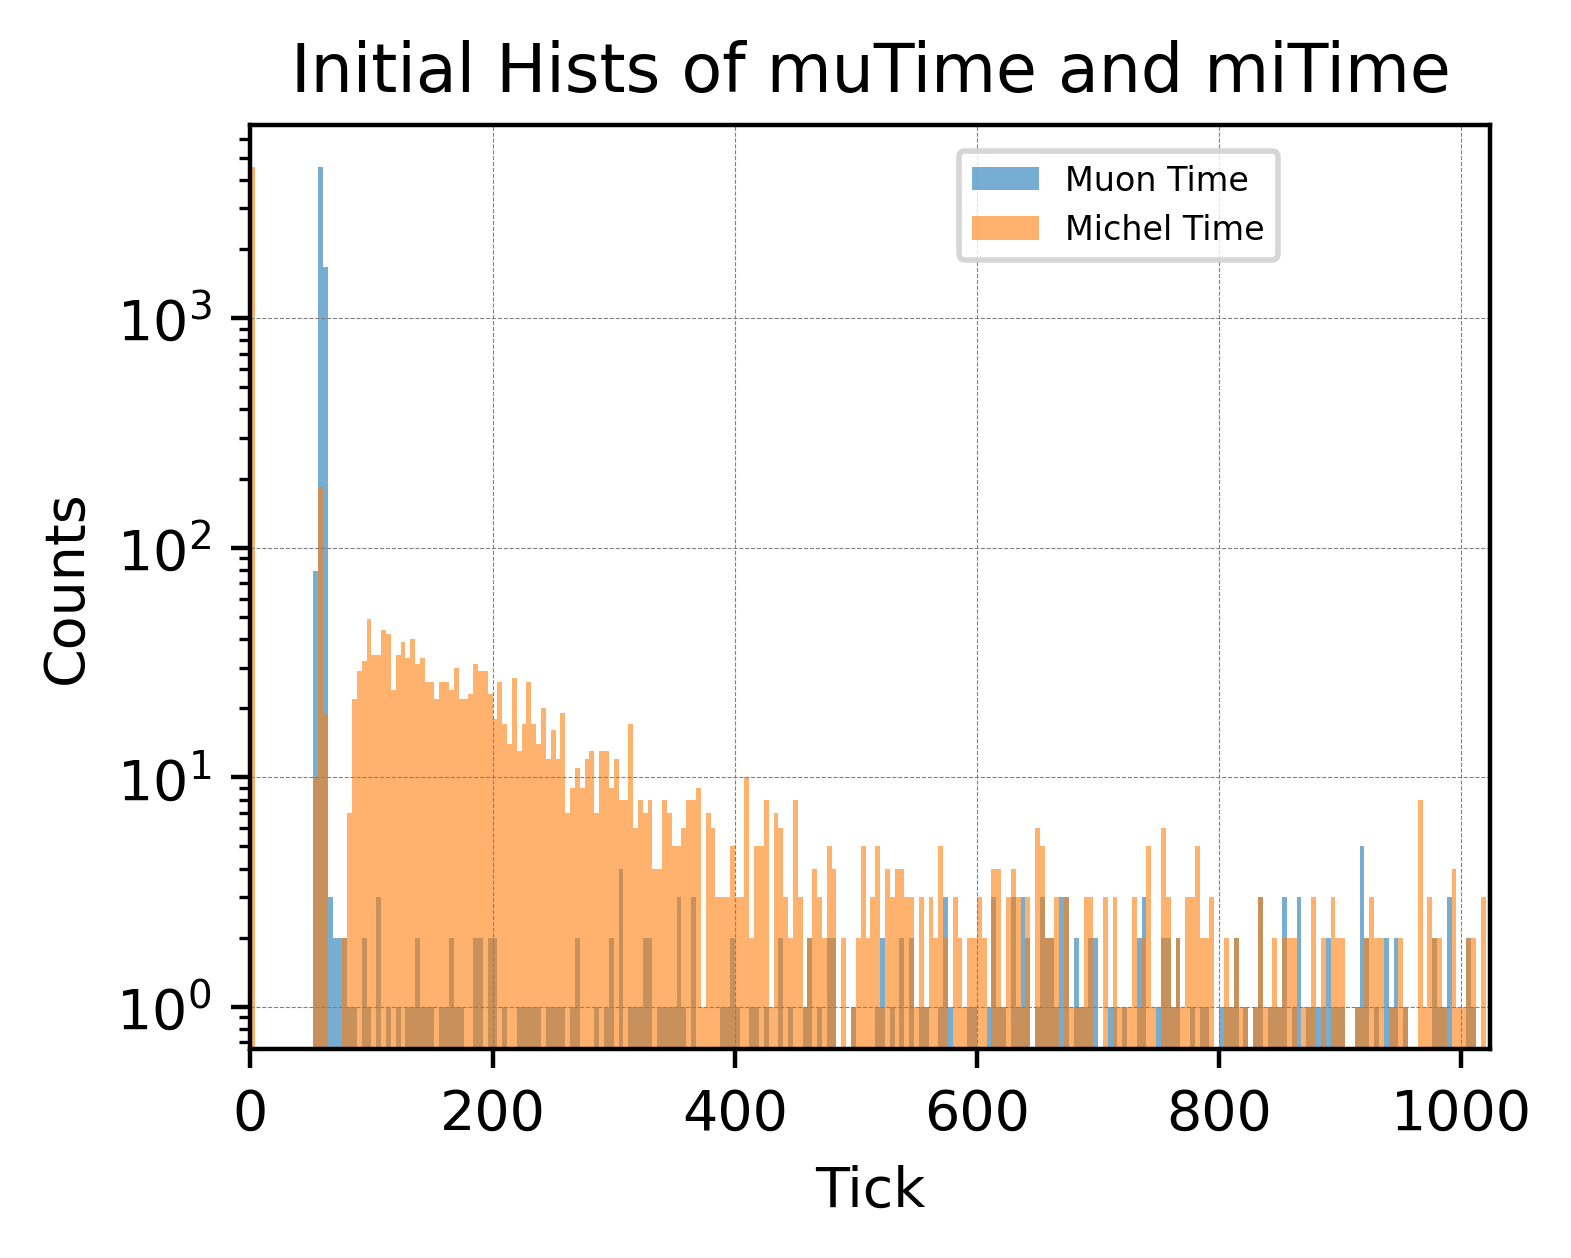

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465






#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(peakFinder_muTime, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(peakFinder_miTime, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title('Initial Hists of muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()


<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals


Muon events purification (mu peak constrained to [55, 65]):

Purified Muon events:  6296 (96.37%)
Length of mu_lifetime (Updated):  6296
Length of updated decayX       :  6296
Length of updated decayY       :  6296
Length of updated decayZ       :  6296


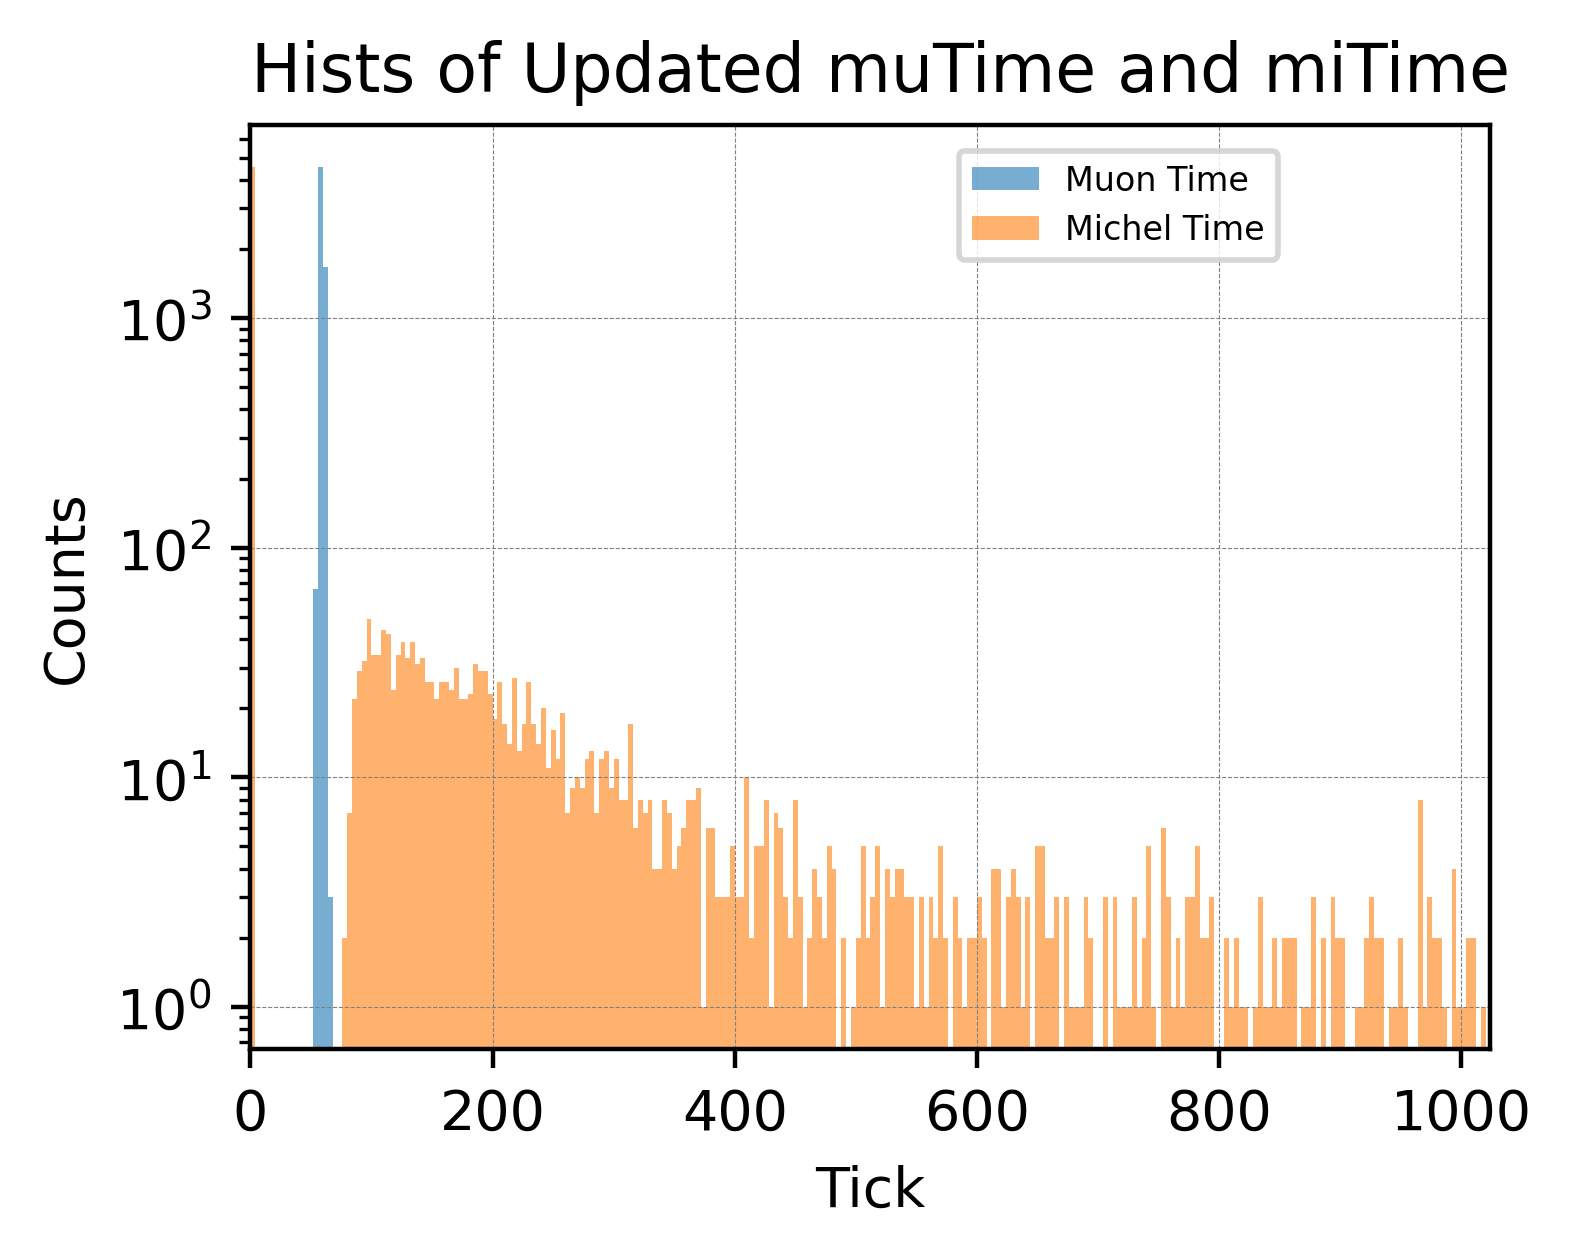




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  6296
# Initial Candidates [0, 16000]:  1763 (28.00%)

Note: If there is no secondary peak (both heights >=0.5) found in summed wvf, the michel time will be recorded as 0 !


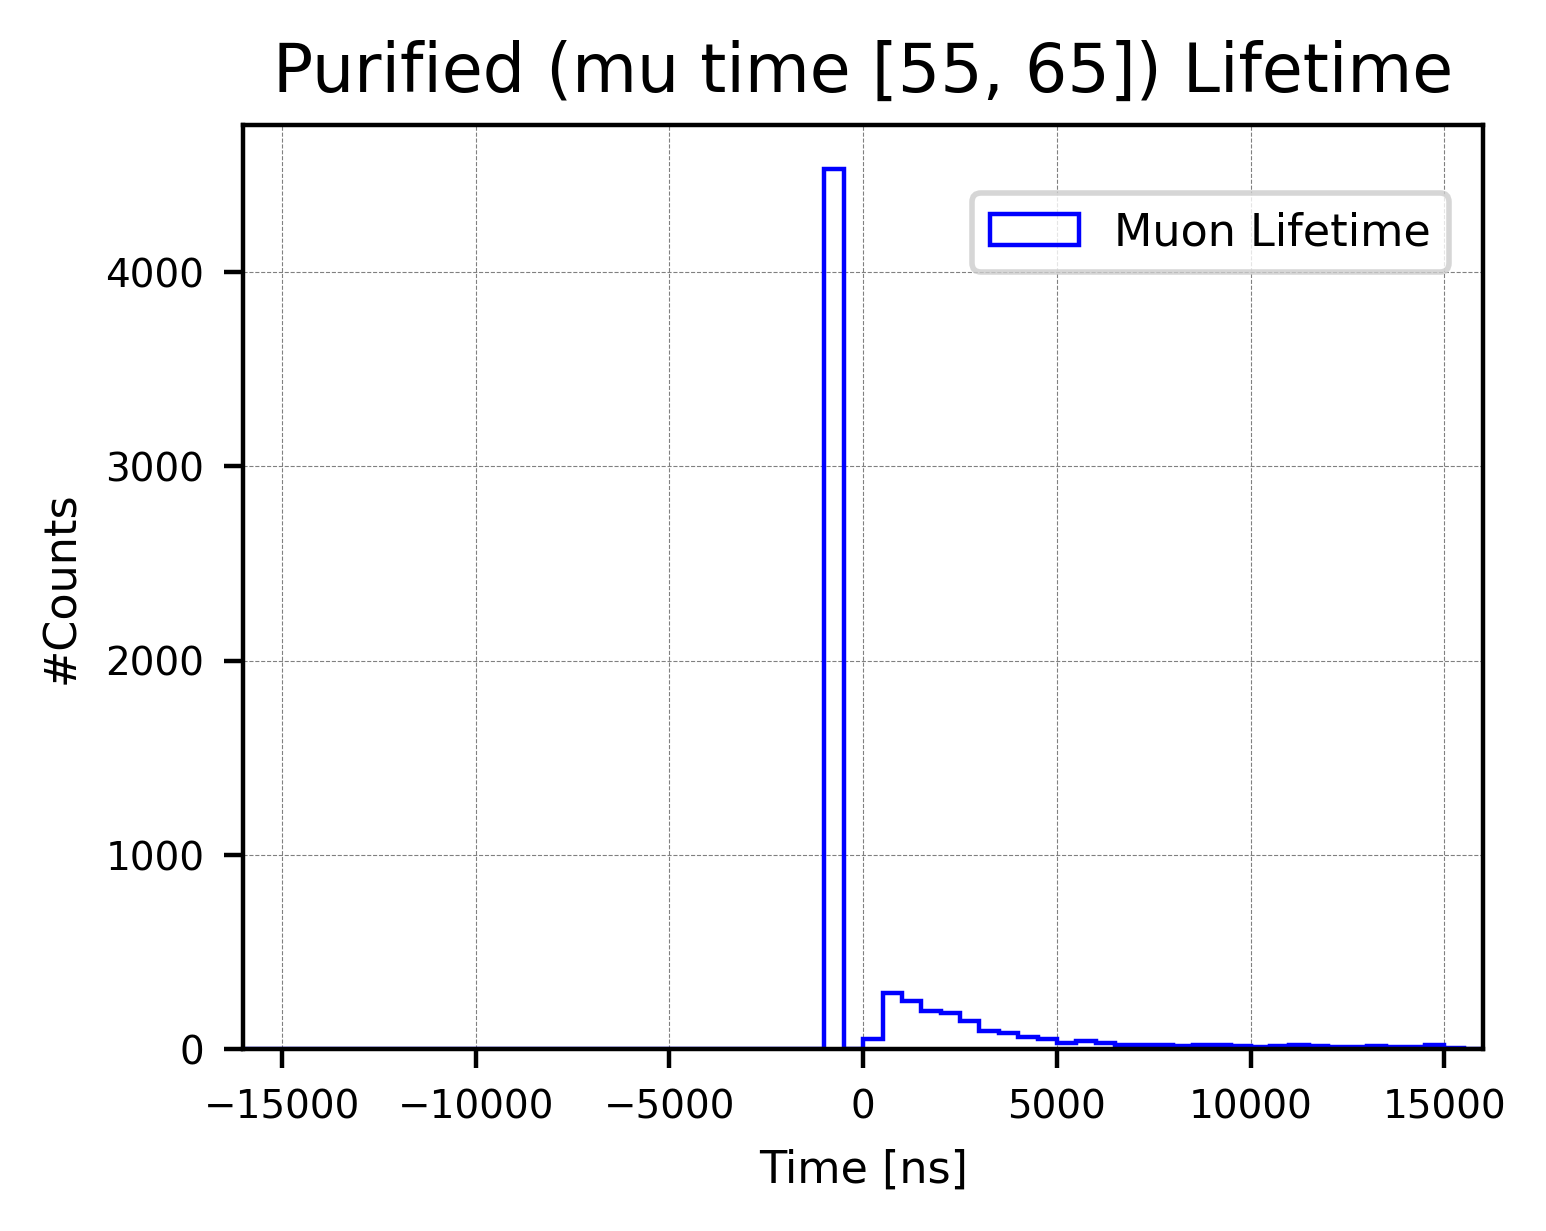

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


#Muon lifetime calculation-------------------------------------------------------------
# Only save muon time located in [55, 65]---
muTime_update = []
miTime_update = []
coin_update = [] #coincidence------
decayX_update = []
decayY_update = []
decayZ_update = []

for i in range(0, len(peakFinder_muTime)):
    mu = peakFinder_muTime[i]
    mi = peakFinder_miTime[i]
    x = decayX[i]
    y = decayY[i]
    z = decayZ[i]

    if 55 <= mu <= 65:
        muTime_update.append(mu)
        miTime_update.append(mi)
        decayX_update.append(x)
        decayY_update.append(y)
        decayZ_update.append(z)

print("\nMuon events purification (mu peak constrained to [55, 65]):")
print("\nPurified Muon events: ", len(muTime_update),
       "({:.2f}%)".format(len(muTime_update)/len(peakFinder_muTime)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
mu_lifetime = [mi - mu for mi, mu in zip(miTime_update, muTime_update)]
print("Length of mu_lifetime (Updated): ", len(mu_lifetime))
print("Length of updated decayX       : ", len(decayX_update))
print("Length of updated decayY       : ", len(decayY_update))
print("Length of updated decayZ       : ", len(decayY_update))









#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title(' Hists of Updated muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()










# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
mu_lifetime_ns = [value * 16 for value in mu_lifetime]
print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(mu_lifetime_ns))

# Apply test cut
mu_lifetime_ns_test = [val for val in mu_lifetime_ns if 0 < val < 16000]
print("# Initial Candidates [0, 16000]: ", len(mu_lifetime_ns_test), "({:.2f}%)".format(len(mu_lifetime_ns_test)/len(mu_lifetime_ns)*100))

print("\nNote: If there is no secondary peak (both heights >=0.5) found in summed wvf, the michel time will be recorded as 0 !")

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(-16000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()














<br />
<br />
<br />
<br />


### Purification 2: Lifetime Cuts

In [40]:


#After lifetime cut---
mu_lifetime_ns_update_2 = []
decayX_update_2 = []
decayY_update_2 = []
decayZ_update_2 = []



for i in range(0, len(mu_lifetime_ns)):
    time = mu_lifetime_ns[i] #mu_lifetime_ns is after "Purification 1"
    x = decayX_update[i]
    y = decayY_update[i]
    z = decayZ_update[i]

    if 500 <= time <= 15500:
        mu_lifetime_ns_update_2.append(time)
        decayX_update_2.append(x)
        decayY_update_2.append(y)
        decayZ_update_2.append(z)            




#Test-------

print("\nAfter peakCoin && Lifetiem cuts:")
print("mu_lifetime_ns_update_2 [500, 15500]: ", len(mu_lifetime_ns_update_2))
print("decayX_update_2        : ", len(decayX_update_2))
print("decayY_update_2        : ", len(decayY_update_2))
print("decayZ_update_2        : ", len(decayZ_update_2))







After peakCoin && Lifetiem cuts:
mu_lifetime_ns_update_2 [500, 15500]:  1713
decayX_update_2        :  1713
decayY_update_2        :  1713
decayZ_update_2        :  1713


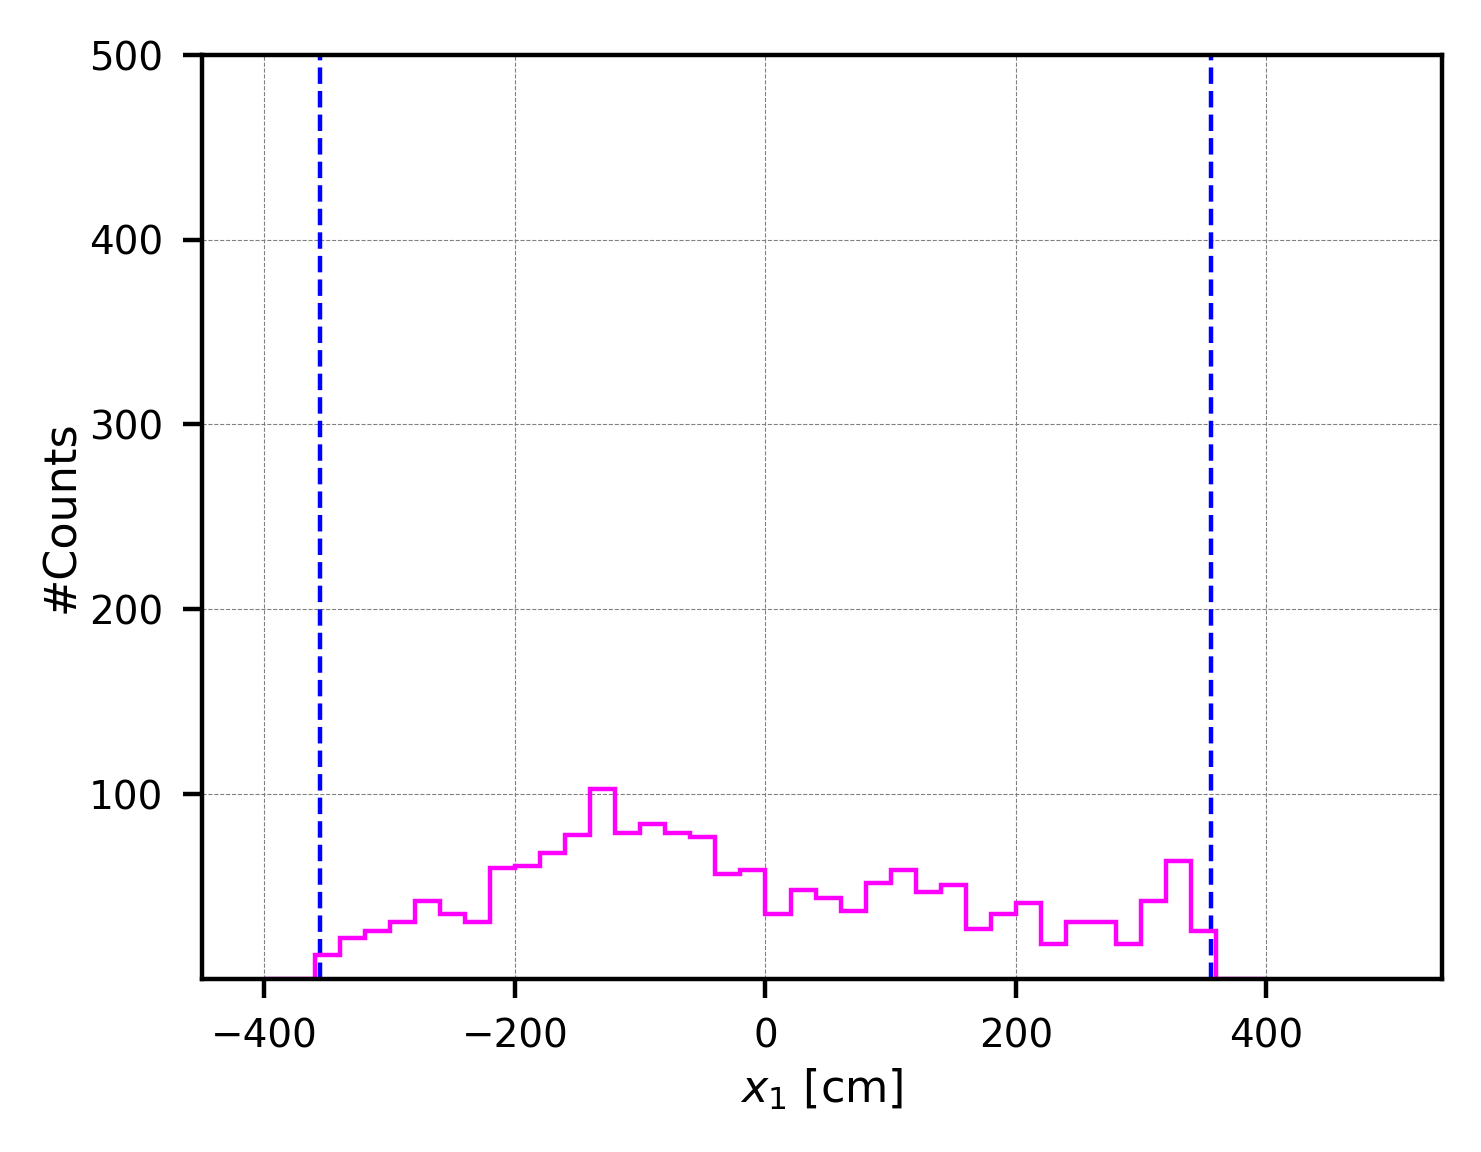

[0, 0, 13, 22, 26, 31, 42, 35, 31, 60, 61, 68, 78, 103, 79, 84, 79, 77, 57, 59, 35, 48, 44, 37, 52, 59, 47, 51, 27, 35, 41, 19, 31, 31, 19, 42, 64, 26, 0, 0]


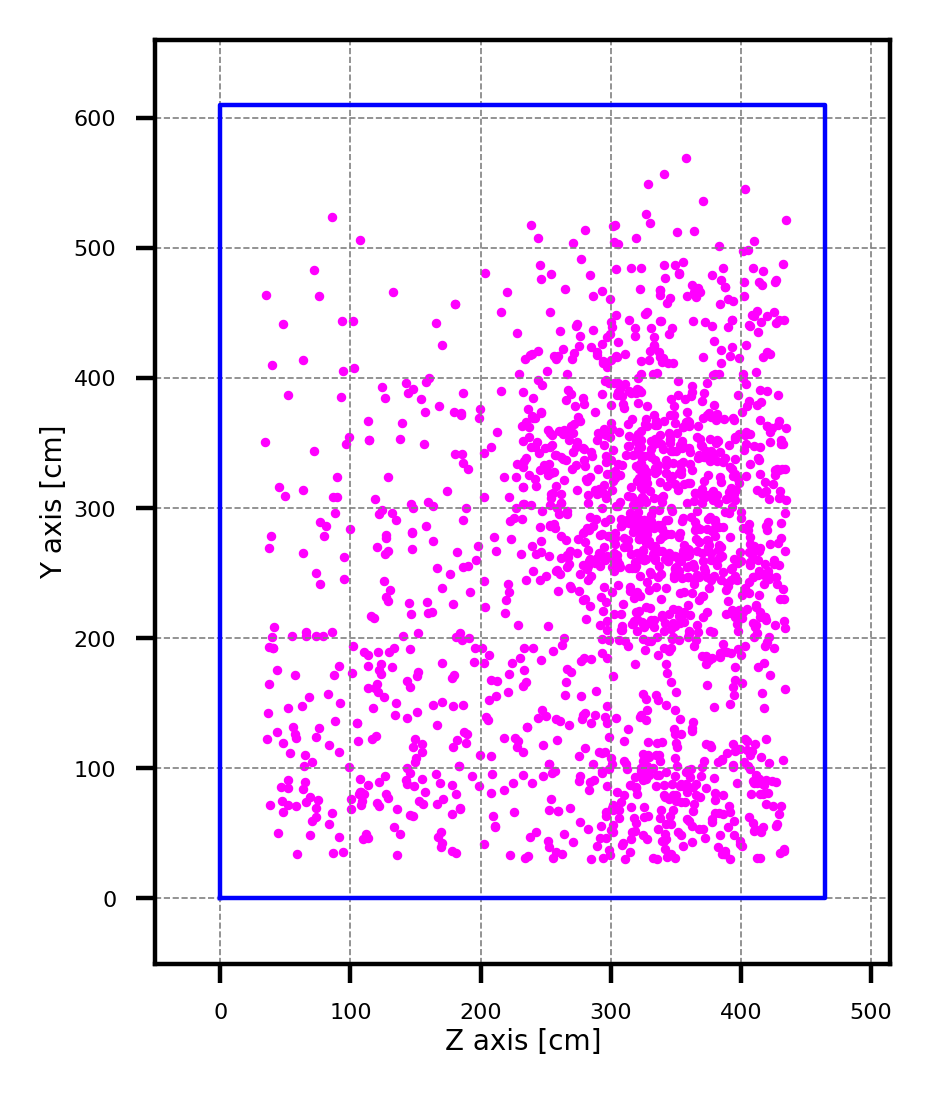

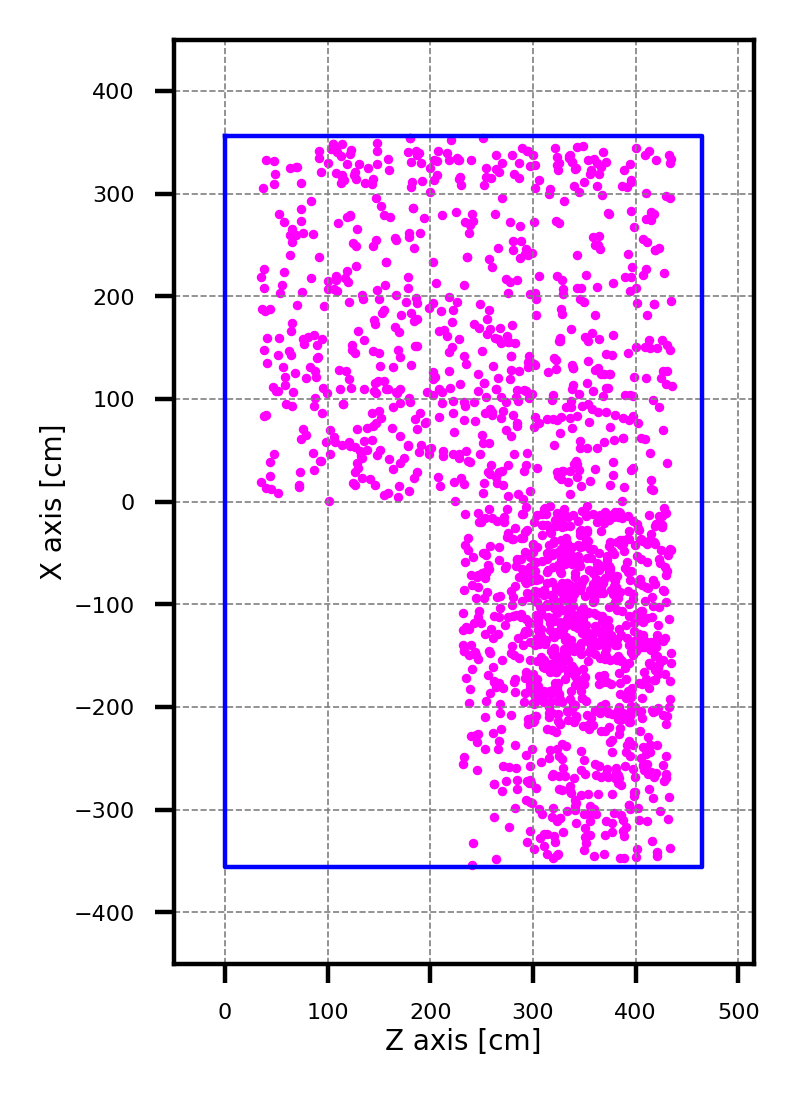

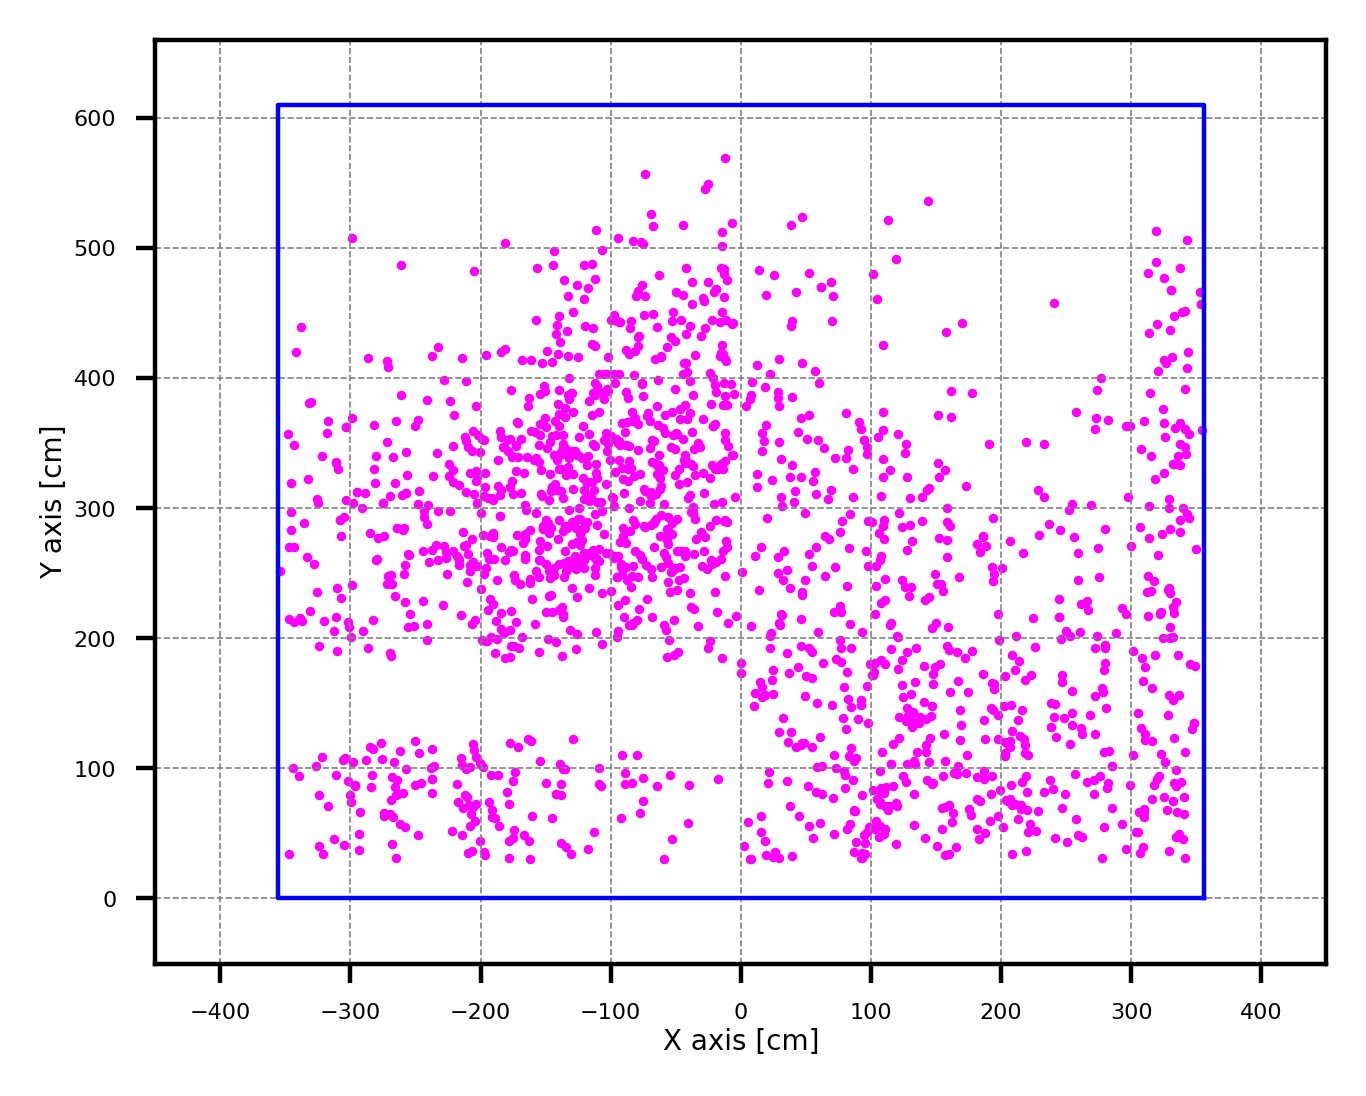

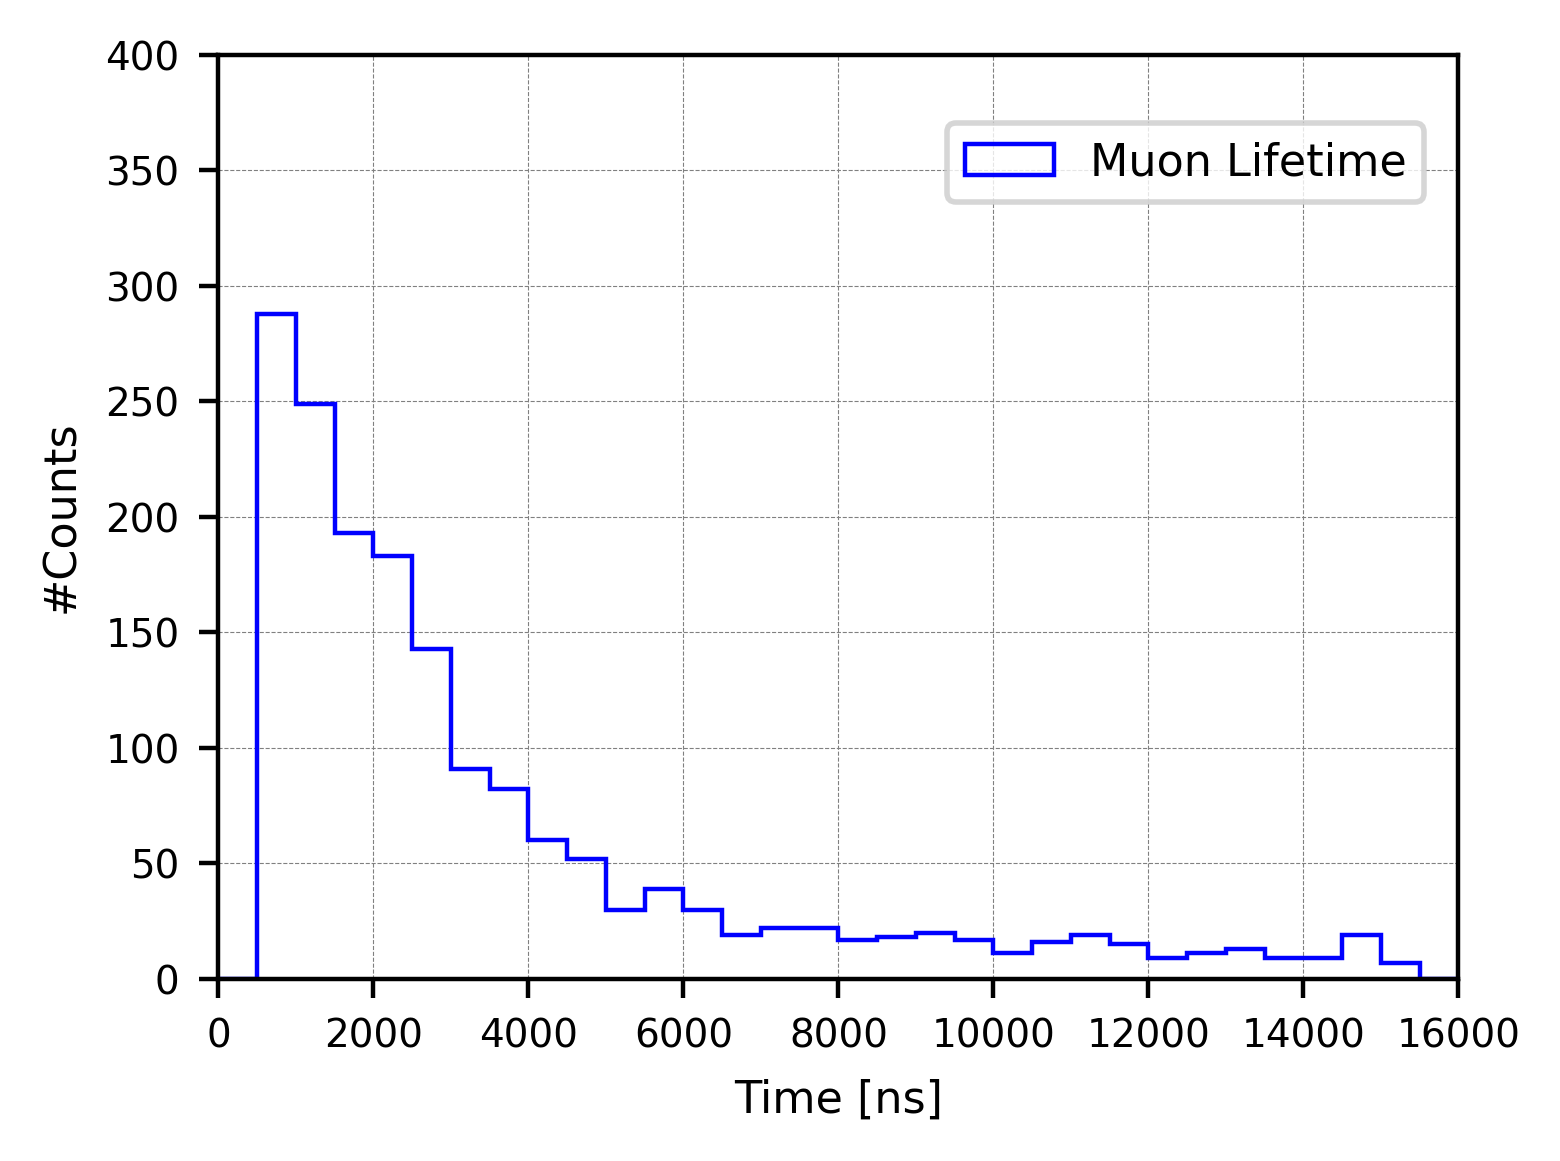


Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 288 ± 17.0
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 249 ± 15.8
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 193 ± 13.9
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 183 ± 13.5
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 143 ± 12.0
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 91 ± 9.5
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 82 ± 9.1
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 60 ± 7.7
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 52 ± 7.2
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 30 ± 5.5
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 39 ± 6.2
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 30 ± 5.5
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 19 ± 4.4
Bin 14: Range = [7000, 7500) | Center = 7250 

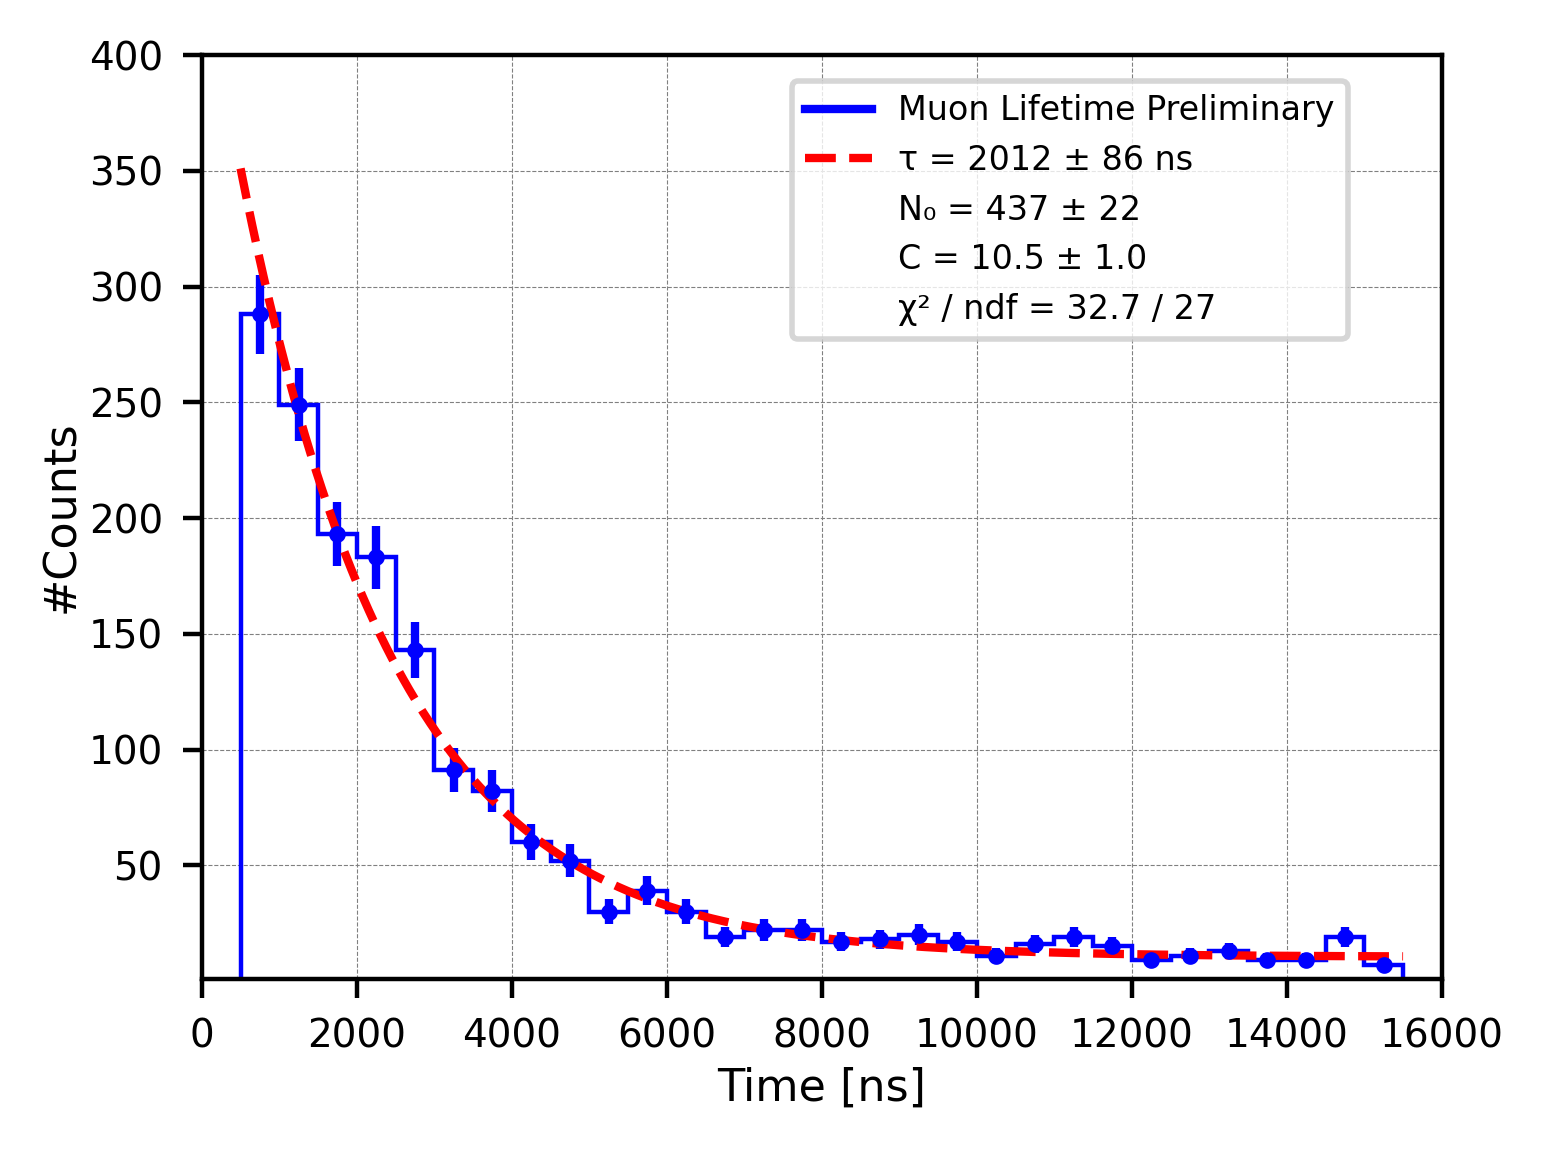

In [41]:
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)
#APA planes---
plt.plot([-356, -356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')
#Define the range and bin width
bin_width = 20
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(decayX_update_2, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()  

# Compute histogram and print bin entries as a list
hist_counts, bin_edges = np.histogram(decayX_update_2, bins=bins, range=(range_min, range_max))
print(hist_counts.tolist())



#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayZ_update_2, decayY_update_2, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayZ_update_2, decayX_update_2, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayX_update_2, decayY_update_2, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 












# Muon Lifetime distribution (NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = 0
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns_update_2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(0, 16000)
plt.ylim(0, 400)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







#Fitting---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_update_2, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8,
                                 label='Muon Lifetime Preliminary')

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)

# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
expected = exp_func(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)  # Avoid division by zero
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Print goodness-of-fit summary
print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Histogram handle
hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()





<br />

### New fitting function:

$$
N(t) = N^+ \cdot \left[ \frac{1}{\tau_{\mu^+}} \cdot e^{-t / \tau_{\mu^+}} + \frac{Q}{\tau_{\mu^+} \cdot R_\mu} \cdot e^{-t / \tau_{\mu^-}} \right] + C
$$

where $N^+$ is the initial number of $\mu^+$, $\tau_{\mu^+} = 2.2\mu s$, $Q=0.988$ is Huff factor, $R=1.277$ is $\mu^+/\mu^-$ flux ratio; $\tau_{\mu^-}$ is the lifetime of $\mu^-$ in liquid argon; C is the expected secondary-muon bkg


Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 288 ± 17.0
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 249 ± 15.8
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 193 ± 13.9
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 183 ± 13.5
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 143 ± 12.0
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 91 ± 9.5
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 82 ± 9.1
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 60 ± 7.7
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 52 ± 7.2
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 30 ± 5.5
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 39 ± 6.2
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 30 ± 5.5
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 19 ± 4.4
Bin 14: Range = [7000, 7500) | Center = 7250 

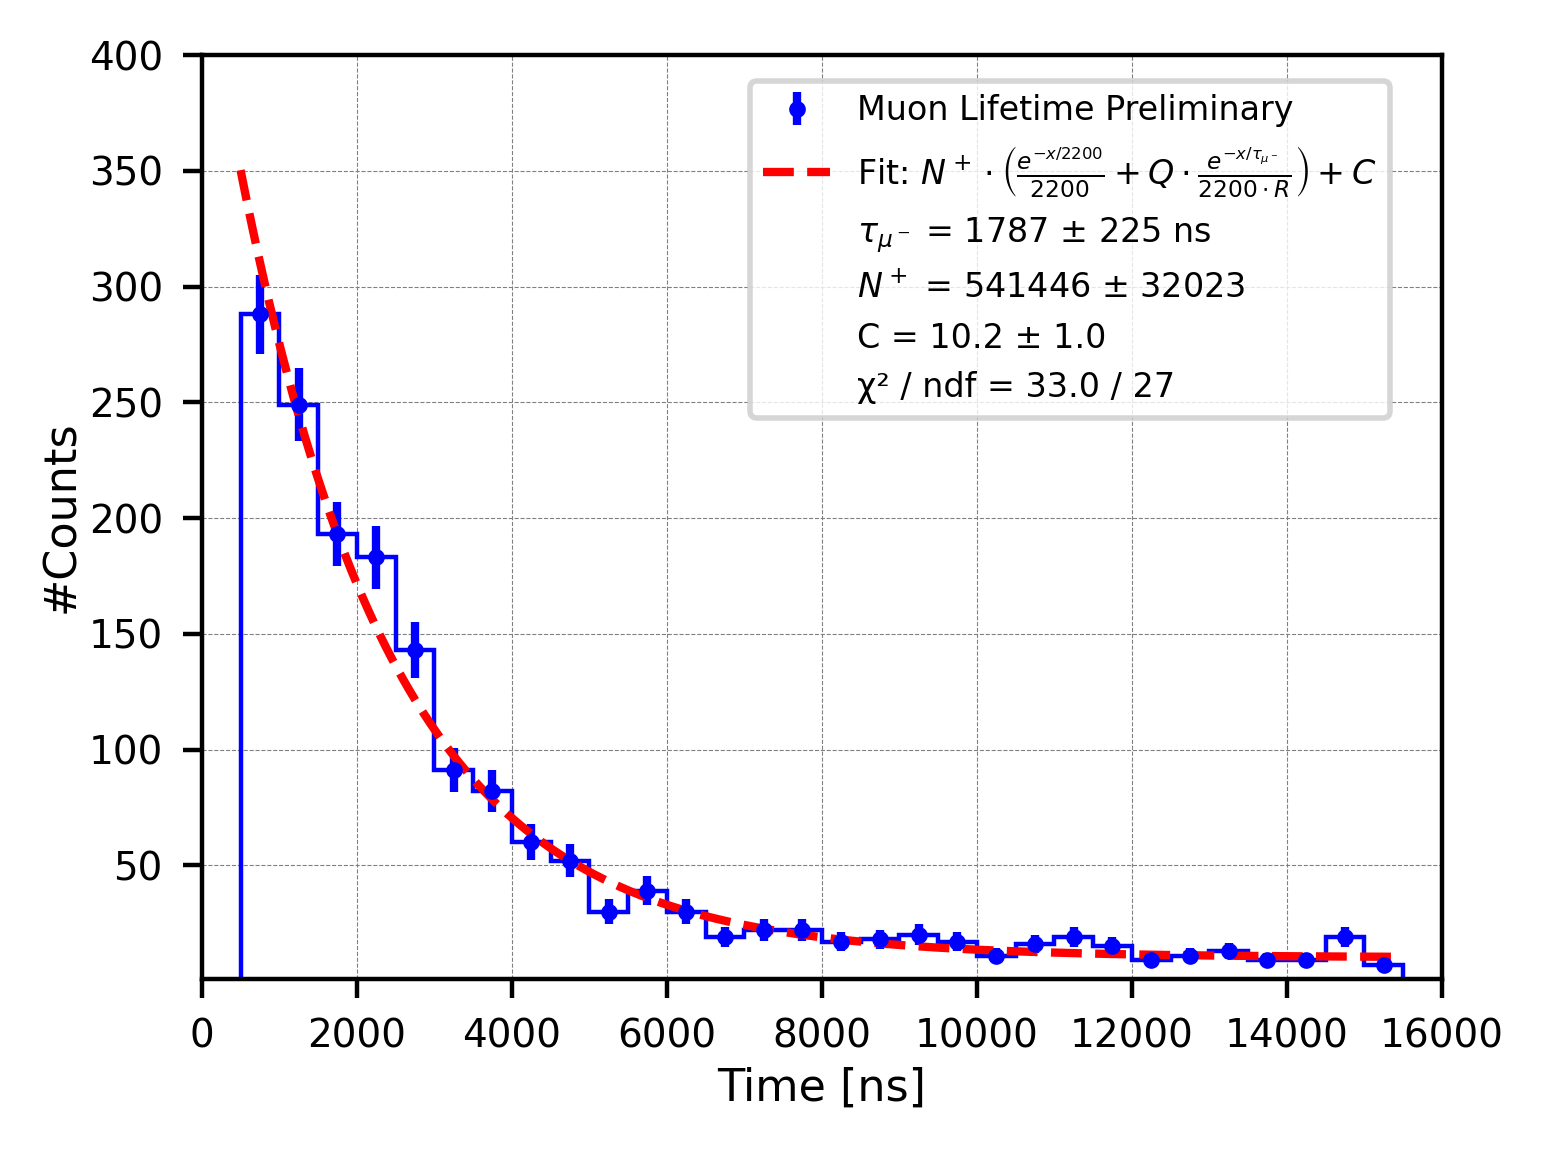

In [23]:
#Plot---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_update_2, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8)

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
hist_handle = plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2, label='Muon Lifetime Preliminary')

# Define the double exponential function with fixed tau_2 = 2200 ns
def exp_func_fixed_tau2(t, N_p, tau_n, C):
    tau_p = 2200  # ns
    Q = 0.988 #Huff factor
    R = 1.277 # flux rate
    return N_p * (np.exp(-t/tau_p)/tau_p + Q*np.exp(-t/tau_n)/(tau_p*R)) + C
#    return N_p * (np.exp(-t/tau_p)/tau_p + Q*np.exp(-t/tau_n)/(tau_n*R)) + C

# Least Squares Method with fixed tau_2-------
# Initial guess: [N1, tau1, N2, C]
popt, pcov = curve_fit(
    exp_func_fixed_tau2, bin_centers, n,
    p0=[max(n)/4*2200, 500, 10],
    sigma=yerr, absolute_sigma=True,
    maxfev=10000,  # increased from default 1000
    bounds=([0, 0, 0],                 # Lower bounds
            [1000*2200, 2500, 50])       # Upper bounds

)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print fitted parameters
print("\nFitted parameters:")
print("$N^+$ = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print(f'$\\tau_{{\\mu^-}}$ = {popt[1]:.2f} ± {perr[1]:.2f} ns')

print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate expected values and chi-squared
expected = exp_func_fixed_tau2(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
#func_text = f'Fit: $N^+ * ( e^{{-x/2200}}/2200 + Q * e^{{-x/\\tau_{{\\mu^-}}}}/(2200 * R) ) + C$'
func_text = f'Fit: $N^+ \\cdot \\left( \\frac{{e^{{-x/2200}}}}{{2200}} + Q \\cdot \\frac{{e^{{-x/\\tau_{{\\mu^-}}}}}}{{2200 \\cdot R}} \\right) + C$'

n1_text = f'$N^+$ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau1_text = f'$\\tau_{{\\mu^-}}$ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func_fixed_tau2(t_fit, *popt), color='red', linestyle='--', label=func_text)

# Dummy handles for displaying additional info in the legend
dummy_tau1 = plt.Line2D([], [], color='none', label=tau1_text)
dummy_n1 = plt.Line2D([], [], color='none', label=n1_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Finalize legend
plt.legend(handles=[hist_handle, fit_line, dummy_tau1, dummy_n1, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()


<br />
<br />
<br />
<br />
<br />
<br />

### Check Detection Rate:

Initial candidates (Space & MS & MH):  12757
Initial candidates && (APA2, 3, 4)  :  11358
Final candidates (Space & MS & MH & wvfCoin & peakCoin & [500, 16000]):  1763 (15.52%)

Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 | 0.250
   -345.0 | 0.353
   -335.0 | 0.462
   -325.0 | 0.484
   -315.0 | 0.462
   -305.0 | 0.571
   -295.0 | 0.529
   -285.0 | 0.455
   -275.0 | 0.375
   -265.0 | 0.571
   -255.0 | 0.553
   -245.0 | 0.288
   -235.0 | 0.288
   -225.0 | 0.293
   -215.0 | 0.353
   -205.0 | 0.416
   -195.0 | 0.304
   -185.0 | 0.305
   -175.0 | 0.331
   -165.0 | 0.236
   -155.0 | 0.214
   -145.0 | 0.253
   -135.0 | 0.265
   -125.0 | 0.213
   -115.0 | 0.205
   -105.0 | 0.103
    -95.0 | 0.123
    -85.0 | 0.117
    -75.0 | 0.074
    -65.0 | 0.095
    -55.0 | 0.072
    -45.0 | 0.056
    -35.0 | 0.043
    -25.0 | 0.035
    -15.0 | 0.052
     -5.0 | 0.025
      5.0 | 0.071
     15.0 | 0.058
     25.0 | 0.063
     35.0 | 0.086
     45.0 | 0.088
     55.0 | 0.129

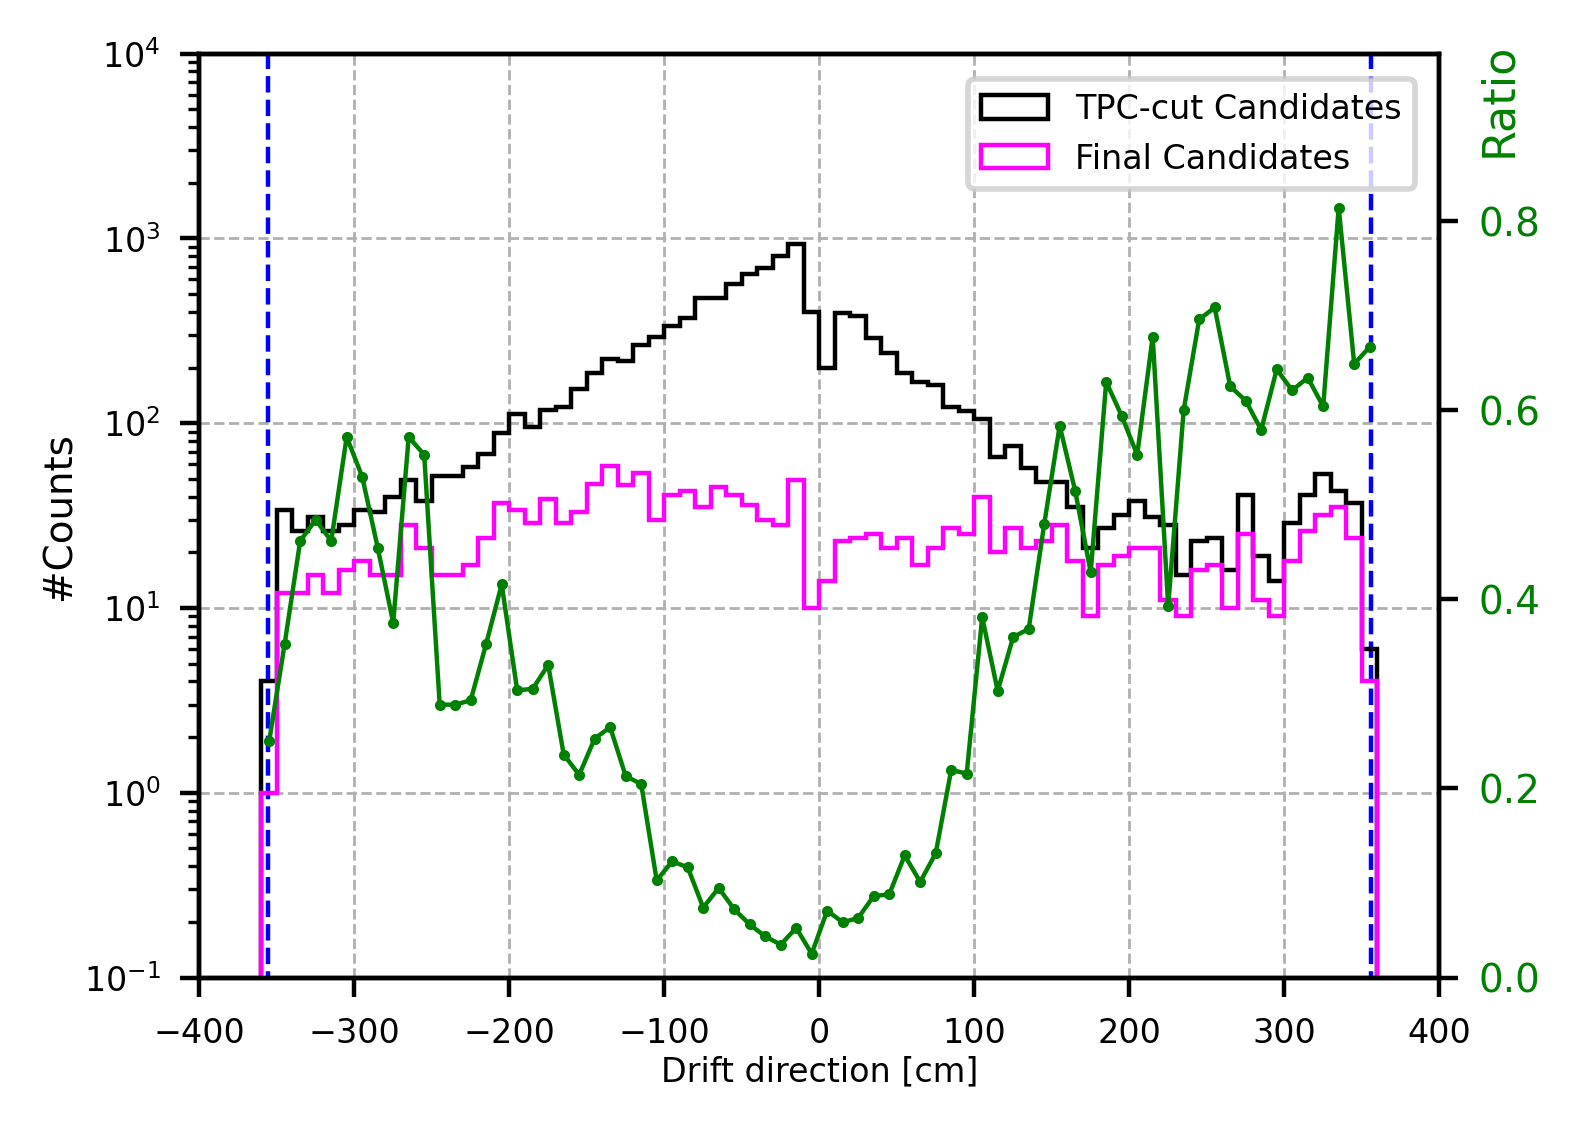

In [24]:
decayX_TPC = []#Candidates after TPC cut---
decayY_TPC = []
decayZ_TPC = []

with open('../statResult/decayX_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX_TPC.append(float(currentPlace))
with open('../statResult/decayY_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY_TPC.append(float(currentPlace))
with open('../statResult/decayZ_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ_TPC.append(float(currentPlace))

#Candidates only in apa2, 3 and 4---
decayX_TPC_apa234 = []
for i in range(0, len(decayX_TPC)):
    x = decayX_TPC[i]
    z = decayZ_TPC[i]
    if x > 0 or (x < 0 and z > 231.266):
        decayX_TPC_apa234.append(x)


print("Initial candidates (Space & MS & MH): ", len(decayX_TPC))
print("Initial candidates && (APA2, 3, 4)  : ", len(decayX_TPC_apa234))
print("Final candidates (Space & MS & MH & wvfCoin & peakCoin & [500, 16000]): ", len(decayX_update_2), 
      "({:.2f}%)".format(len(decayX_update_2)/len(decayX_TPC_apa234)*100))




# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Histogram counts ---
n_initial, _ = np.histogram(decayX_TPC_apa234, bins=bins)
n_final, _ = np.histogram(decayX_update_2, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio = []
ratio_centers = []

print("\nBin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial, n_final):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio.append(r)
        ratio_centers.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


# Filter out NaN values for min/max calculation
valid_ratios = [r for r in ratio if not np.isnan(r)]

if valid_ratios:
    print("\nMaximum ratio: {:.3f}".format(np.max(valid_ratios)))
    print("Minimum ratio: {:.3f}".format(np.min(valid_ratios)))
else:
    print("\nNo valid ratios to compute min/max.")


#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')


# Plot histograms
ax1.hist(bins[:-1], bins=bins, weights=n_initial, edgecolor='black',
         histtype='step', linewidth=0.8, label='TPC-cut Candidates')
ax1.hist(bins[:-1], bins=bins, weights=n_final, edgecolor='magenta',
         histtype='step', linewidth=0.8, label='Final Candidates')


ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-400, 400)
ax1.set_ylim(0.1, 10000)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.set_yscale('log')
ax1.tick_params(labelsize=6)


# Secondary y-axis for ratio
ax2 = ax1.twinx()

ax2.plot(ratio_centers, ratio, 'o-', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=8, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.95)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)


# Final layout
#plt.tight_layout()
plt.show()



<br />

#### Split into 4 TPC chambers:

Candidates after TPC cuts:
#decayX_TPC:  12757
#decayX_TPC_apa24:  9893 (77.55%)
#decayX_TPC_apa3:  2864 (22.45%)

Final candidates:
#decayX_update_2:  1763
#decayX_update_2_apa24:  1409 (79.92%)
#decayX_update_2_apa3:  354 (20.08%)


------ APA2 & APA4: ------
Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 | 0.250
   -345.0 | 0.353
   -335.0 | 0.462
   -325.0 | 0.484
   -315.0 | 0.462
   -305.0 | 0.571
   -295.0 | 0.529
   -285.0 | 0.455
   -275.0 | 0.375
   -265.0 | 0.571
   -255.0 | 0.553
   -245.0 | 0.288
   -235.0 | 0.288
   -225.0 | 0.293
   -215.0 | 0.353
   -205.0 | 0.416
   -195.0 | 0.304
   -185.0 | 0.305
   -175.0 | 0.331
   -165.0 | 0.236
   -155.0 | 0.214
   -145.0 | 0.253
   -135.0 | 0.265
   -125.0 | 0.213
   -115.0 | 0.205
   -105.0 | 0.103
    -95.0 | 0.123
    -85.0 | 0.117
    -75.0 | 0.074
    -65.0 | 0.095
    -55.0 | 0.072
    -45.0 | 0.056
    -35.0 | 0.043
    -25.0 | 0.035
    -15.0 | 0.052
     -5.0 | 0.025
      5.0 | 0.060
     

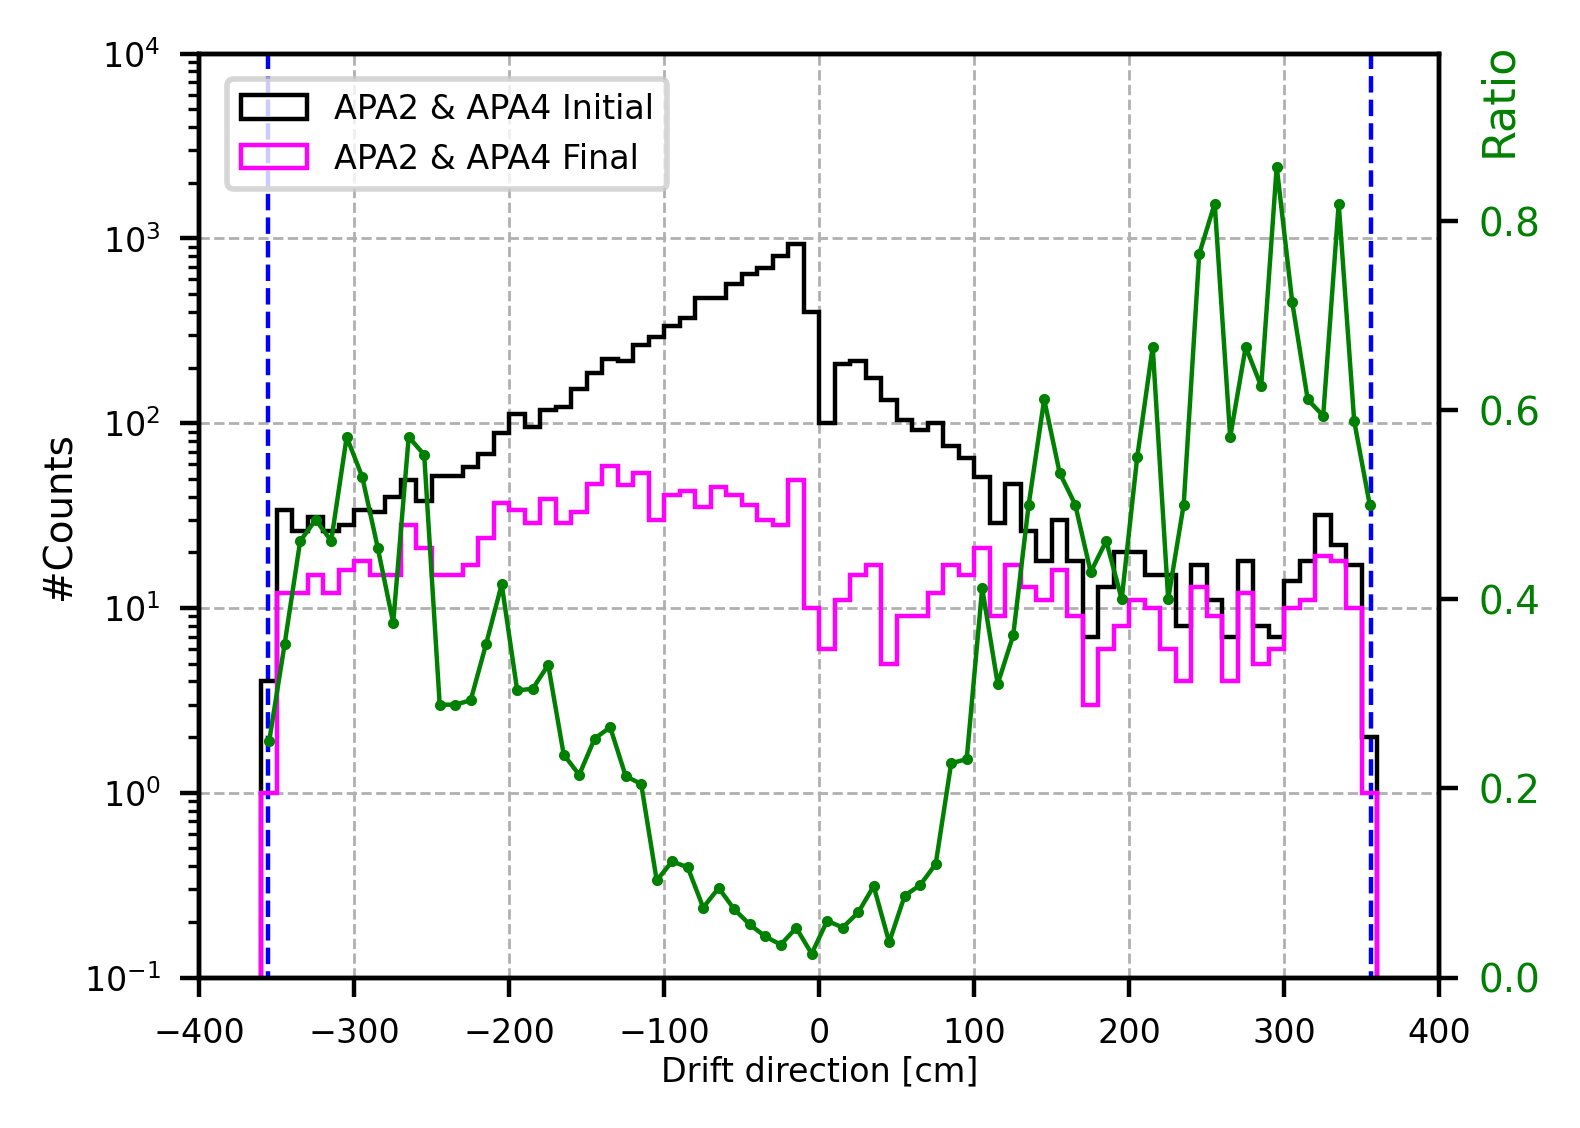

In [25]:
#After TPC cut:
decayX_TPC_apa24 = []#Candidates for APA 2 and 4---
decayX_TPC_apa3 = []

for i in range(0, len(decayZ_TPC)):
    z = decayZ_TPC[i]
    x = decayX_TPC[i]

    if z > 231.266:
        decayX_TPC_apa24.append(x)
    else:
        decayX_TPC_apa3.append(x)

print("Candidates after TPC cuts:")
print("#decayX_TPC: ", len(decayX_TPC))
print("#decayX_TPC_apa24: ", len(decayX_TPC_apa24), "({:.2f}%)".format(len(decayX_TPC_apa24)/len(decayX_TPC)*100))
print("#decayX_TPC_apa3: ", len(decayX_TPC_apa3), "({:.2f}%)".format(len(decayX_TPC_apa3)/len(decayX_TPC)*100))

#Final candidates:
decayX_update_2_apa24 = []
decayX_update_2_apa3 = []

for i in range(0, len(decayZ_update_2)):
    z = decayZ_update_2[i]
    x = decayX_update_2[i]

    if z > 231.266:
        decayX_update_2_apa24.append(x)
    else:
        decayX_update_2_apa3.append(x)

print("\nFinal candidates:")
print("#decayX_update_2: ", len(decayX_update_2))
print("#decayX_update_2_apa24: ", len(decayX_update_2_apa24), 
      "({:.2f}%)".format(len(decayX_update_2_apa24)/len(decayX_update_2)*100))
print("#decayX_update_2_apa3: ", len(decayX_update_2_apa3), 
      "({:.2f}%)".format(len(decayX_update_2_apa3)/len(decayX_update_2)*100))





# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

#APA2 & APA4--------------------------------------------
# --- Histogram counts ---
n_initial_apa24, _ = np.histogram(decayX_TPC_apa24, bins=bins)
n_final_apa24, _ = np.histogram(decayX_update_2_apa24, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio_apa24 = []
ratio_centers_apa24 = []

print("\n\n------ APA2 & APA4: ------")
print("Bin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial_apa24, n_final_apa24):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio_apa24.append(r)
        ratio_centers_apa24.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")



#APA3--------------------------------------------
# --- Histogram counts ---
n_initial_apa3, _ = np.histogram(decayX_TPC_apa3, bins=bins)
n_final_apa3, _ = np.histogram(decayX_update_2_apa3, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio_apa3 = []
ratio_centers_apa3 = []

print("\n\n------ APA3: ------")
print("Bin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial_apa3, n_final_apa3):
    if 0 <= center <= 350: # x=355, the entry is zero---
        r = nf / ni if ni > 0 else np.nan
        ratio_apa3.append(r)
        ratio_centers_apa3.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")



#APA planes-------------
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')


# Plot histograms
#APA 2 & 4---
ax1.hist(bins[:-1], bins=bins, weights=n_initial_apa24, edgecolor='black',
         histtype='step', linewidth=0.8, label='APA2 & APA4 Initial')
ax1.hist(bins[:-1], bins=bins, weights=n_final_apa24, edgecolor='magenta',
         histtype='step', linewidth=0.8, label='APA2 & APA4 Final')

#APA 3---
#ax1.hist(bins[:-1], bins=bins, weights=n_initial_apa3, edgecolor='black',
#         histtype='step', linewidth=0.8, label='APA3 Initial')
#ax1.hist(bins[:-1], bins=bins, weights=n_final_apa3, edgecolor='magenta',
#         histtype='step', linewidth=0.8, label='APA3 Final')


ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.2, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-400, 400)
ax1.set_ylim(0.1, 10000)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.set_yscale('log')
ax1.tick_params(labelsize=6)



# Secondary y-axis for ratio
ax2 = ax1.twinx()


#APA2 & APA4:
ax2.plot(ratio_centers_apa24, ratio_apa24, 'o-', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

#APA3:
#ax2.plot(ratio_centers_apa3, ratio_apa3, 'o-', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=8, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.95)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)


# Final layout
#plt.tight_layout()
plt.show()










<br />


### Among beam direction:

Candidates after TPC cuts:
#decayZ_TPC:  12757
#decayZ_TPC_apa12:  9530 (74.70%)
#decayZ_TPC_apa34:  3227 (25.30%)

Final candidates:
#decayZ_update_2:  1763
#decayZ_update_2_apa12:  1031 (58.48%)
#decayZ_update_2_apa34:  732 (41.52%)


------ APA1 & APA2: ------
Bin Center | Final / Initial Ratio
-------------------------------
     35.0 | 0.000
     45.0 | 0.000
     55.0 | 0.000
     65.0 | 0.000
     75.0 | 0.000
     85.0 | 0.000
     95.0 | 0.000
    105.0 | 0.000
    115.0 | 0.000
    125.0 | 0.000
    135.0 | 0.000
    145.0 | 0.000
    155.0 | 0.000
    165.0 | 0.000
    175.0 | 0.000
    185.0 | 0.000
    195.0 | 0.000
    205.0 | 0.000
    215.0 | 0.000
    225.0 | 0.000
    235.0 | 0.074
    245.0 | 0.072
    255.0 | 0.062
    265.0 | 0.070
    275.0 | 0.058
    285.0 | 0.068
    295.0 | 0.123
    305.0 | 0.138
    315.0 | 0.165
    325.0 | 0.177
    335.0 | 0.172
    345.0 | 0.171
    355.0 | 0.132
    365.0 | 0.129
    375.0 | 0.147
    385.0 | 0.140
    395.0 | 0.135
   

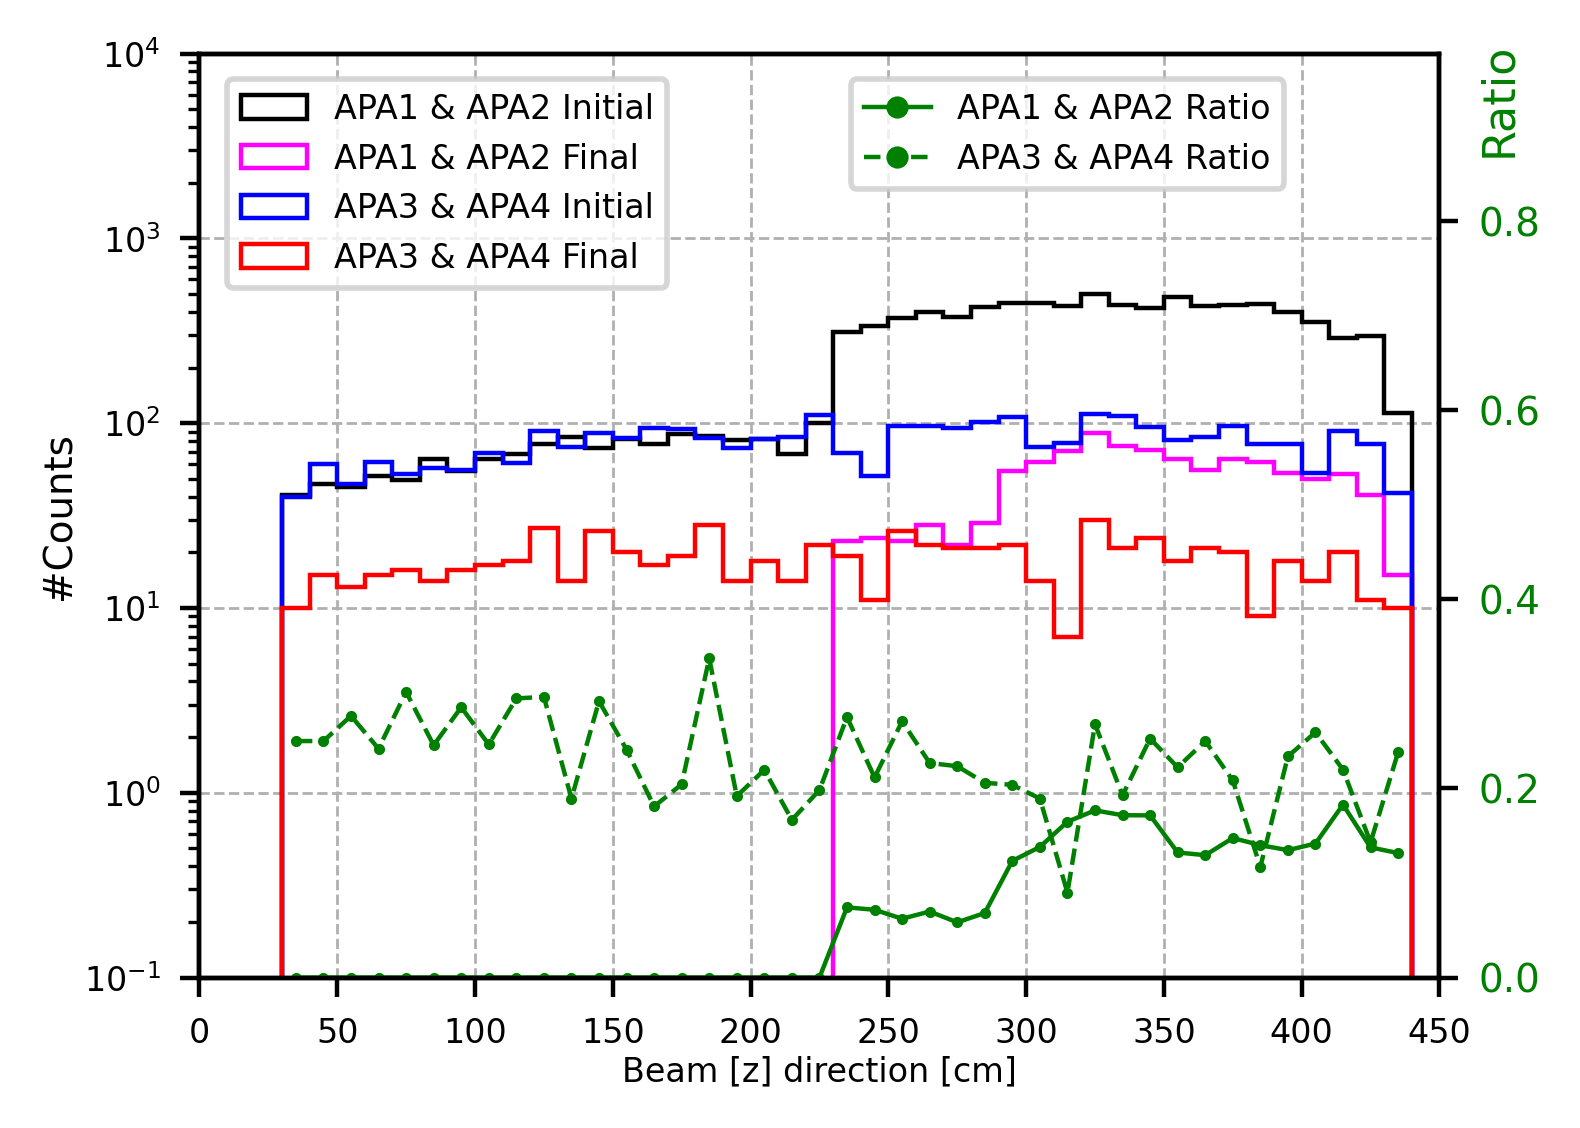

In [26]:
#After TPC cut:
decayZ_TPC_apa12 = []#Candidates for APA 2 and 4---
decayZ_TPC_apa34 = []

for i in range(0, len(decayZ_TPC)):
    z = decayZ_TPC[i]
    x = decayX_TPC[i]

    if x < 0:
        decayZ_TPC_apa12.append(z)
    else:
        decayZ_TPC_apa34.append(z)

print("Candidates after TPC cuts:")
print("#decayZ_TPC: ", len(decayZ_TPC))
print("#decayZ_TPC_apa12: ", len(decayZ_TPC_apa12), "({:.2f}%)".format(len(decayZ_TPC_apa12)/len(decayZ_TPC)*100))
print("#decayZ_TPC_apa34: ", len(decayZ_TPC_apa34), "({:.2f}%)".format(len(decayZ_TPC_apa34)/len(decayZ_TPC)*100))


#Final candidates:
decayZ_update_2_apa12 = []
decayZ_update_2_apa34 = []

for i in range(0, len(decayZ_update_2)):
    z = decayZ_update_2[i]
    x = decayX_update_2[i]

    if x < 0:
        decayZ_update_2_apa12.append(z)
    else:
        decayZ_update_2_apa34.append(z)

print("\nFinal candidates:")
print("#decayZ_update_2: ", len(decayZ_update_2))
print("#decayZ_update_2_apa12: ", len(decayZ_update_2_apa12), 
      "({:.2f}%)".format(len(decayZ_update_2_apa12)/len(decayZ_update_2)*100))
print("#decayZ_update_2_apa34: ", len(decayZ_update_2_apa34), 
      "({:.2f}%)".format(len(decayZ_update_2_apa34)/len(decayZ_update_2)*100))








# Plotting the histogram (X distribution)-------------------------------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = 0
range_max = 450
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

#APA12--------------------------------------------
# --- Histogram counts ---
n_initial_apa12, _ = np.histogram(decayZ_TPC_apa12, bins=bins)
n_final_apa12, _ = np.histogram(decayZ_update_2_apa12, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio_apa12 = []
ratio_centers_apa12 = []

print("\n\n------ APA1 & APA2: ------")
print("Bin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial_apa12, n_final_apa12):
    if 30 <= center <= 440:
        r = nf / ni if ni > 0 else np.nan
        ratio_apa12.append(r)
        ratio_centers_apa12.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


#APA34--------------------------------------------
# --- Histogram counts ---
n_initial_apa34, _ = np.histogram(decayZ_TPC_apa34, bins=bins)
n_final_apa34, _ = np.histogram(decayZ_update_2_apa34, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio_apa34 = []
ratio_centers_apa34 = []

print("\n\n------ APA3 & APA4: ------")
print("Bin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial_apa34, n_final_apa34):
    if 30 <= center <= 440:
        r = nf / ni if ni > 0 else np.nan
        ratio_apa34.append(r)
        ratio_centers_apa34.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")




# Plot histograms
#APA 1 & 2---
ax1.hist(bins[:-1], bins=bins, weights=n_initial_apa12, edgecolor='black',
         histtype='step', linewidth=0.8, label='APA1 & APA2 Initial')
ax1.hist(bins[:-1], bins=bins, weights=n_final_apa12, edgecolor='magenta',
         histtype='step', linewidth=0.8, label='APA1 & APA2 Final')

#APA 3 & 4---
ax1.hist(bins[:-1], bins=bins, weights=n_initial_apa34, edgecolor='blue',
         histtype='step', linewidth=0.8, label='APA3 & APA4 Initial')
ax1.hist(bins[:-1], bins=bins, weights=n_final_apa34, edgecolor='red',
         histtype='step', linewidth=0.8, label='APA3 & APA4 Final')


ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.2, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(0, 450)
ax1.set_ylim(0.1, 10000)
ax1.set_xlabel('Beam [z] direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.set_yscale('log')
ax1.tick_params(labelsize=6)



# Secondary y-axis for ratio
ax2 = ax1.twinx()


#APA1 & 2:
ax2.plot(ratio_centers_apa12, ratio_apa12, 'o-', color='green', markersize=1, linewidth=0.8, label='APA1 & APA2 Ratio')

#APA3 & 4:
ax2.plot(ratio_centers_apa34, ratio_apa34, 'o--', color='green', markersize=1, linewidth=0.8, label='APA3 & APA4 Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=8, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.95)  # (x, y) in axis coordinates
ax2.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=3, ncol=1, prop={'size': 6})
ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)


# Final layout
#plt.tight_layout()
plt.show()






<br />
<br />
<br />
<br />

## Space Cut Efficiency Presentation:

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D



# Specify the file name
#read data---
decayX_initial = []
decayY_initial = []
decayZ_initial = []
michelScore_initial = []
michelHits_initial = []


with open('./statResult/decayX_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX_initial.append(float(currentPlace))
with open('./statResult/decayY_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY_initial.append(float(currentPlace))
with open('./statResult/decayZ_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ_initial.append(float(currentPlace))
        
with open('./statResult/michelScore_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        michelScore_initial.append(float(currentPlace))
with open('./statResult/michelHits_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        michelHits_initial.append(float(currentPlace))        




print("Length of decayX: ", len(decayX_initial))
print("Length of decayY: ", len(decayY_initial))
print("Length of decayZ: ", len(decayZ_initial))
print("Length of michelScore: ", len(michelScore_initial))
print("Length of michelHits: ", len(michelHits_initial))


Length of decayX:  79286
Length of decayY:  79286
Length of decayZ:  79286
Length of michelScore:  79286
Length of michelHits:  79286


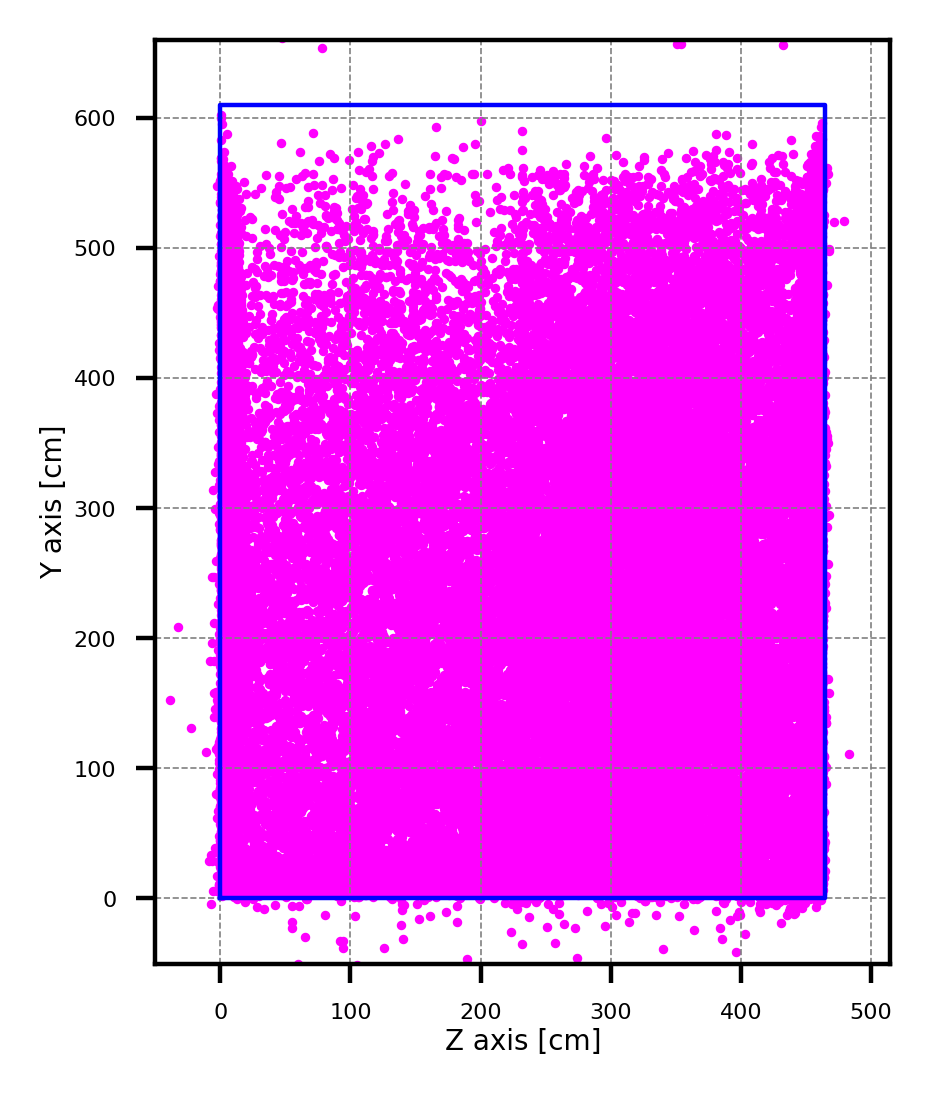

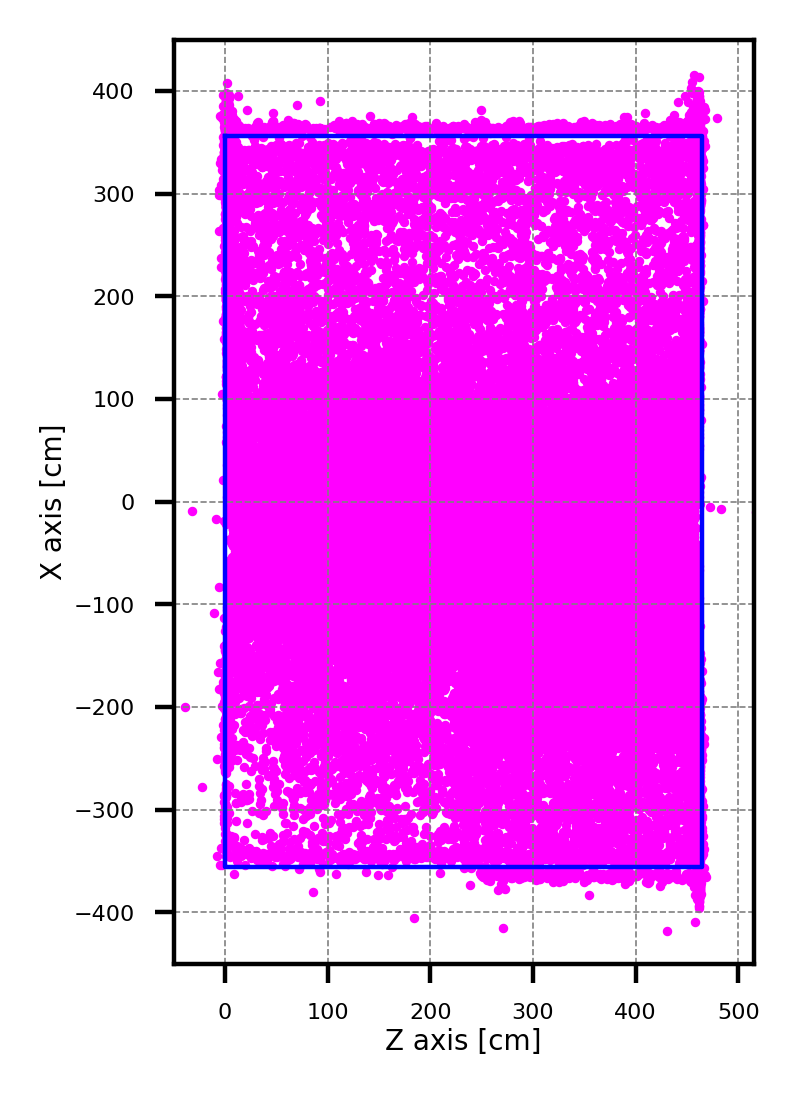

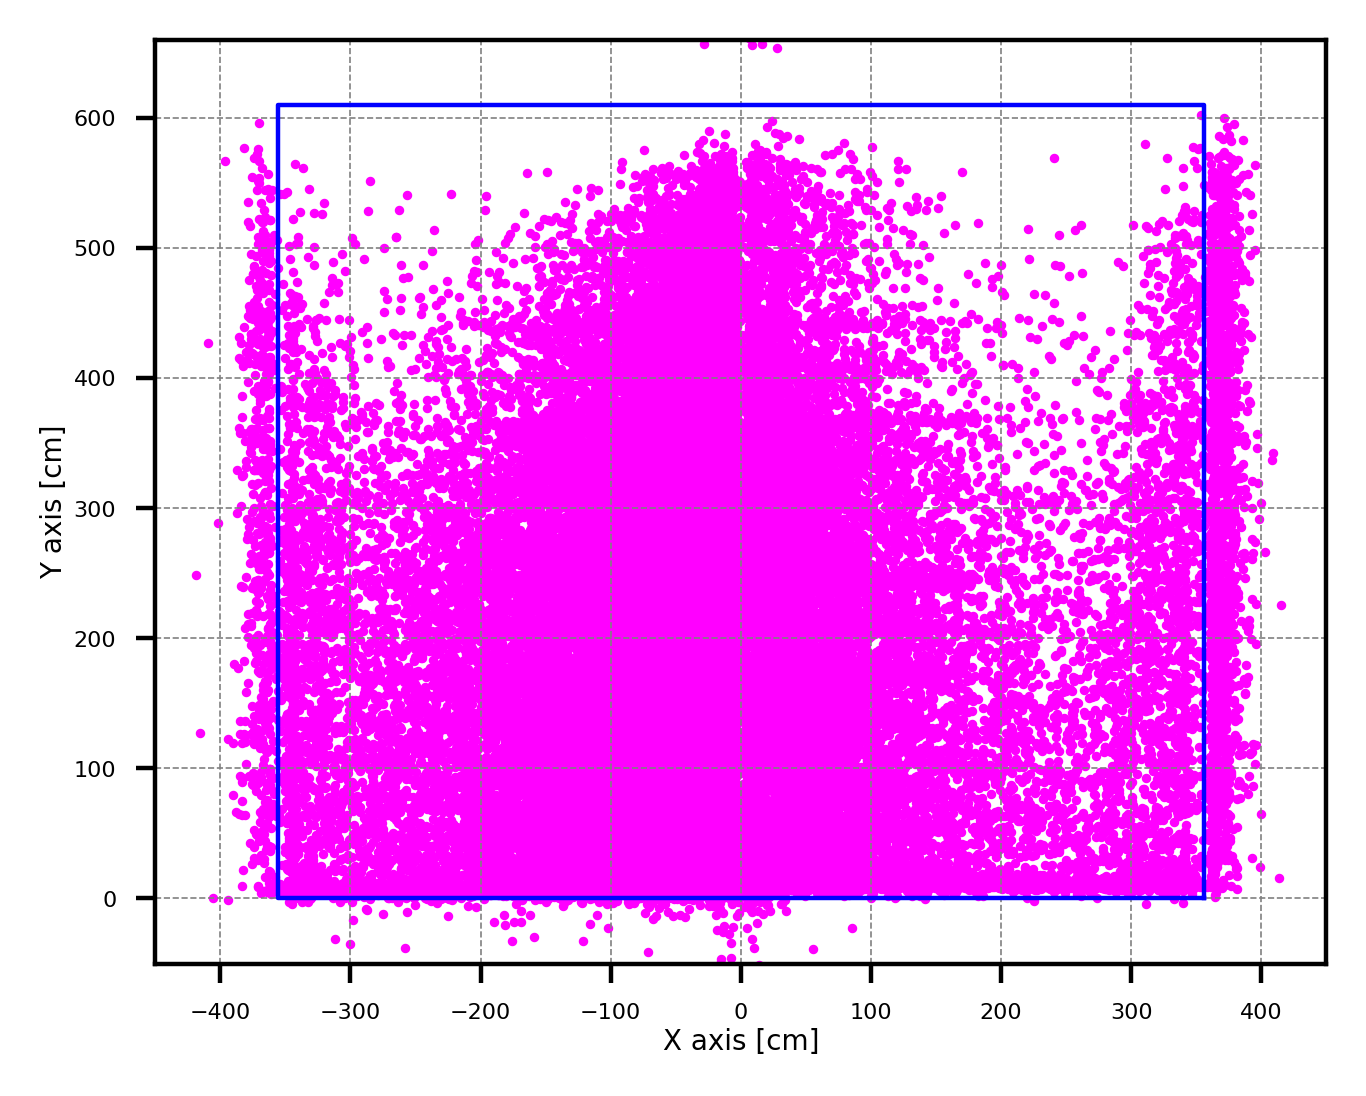

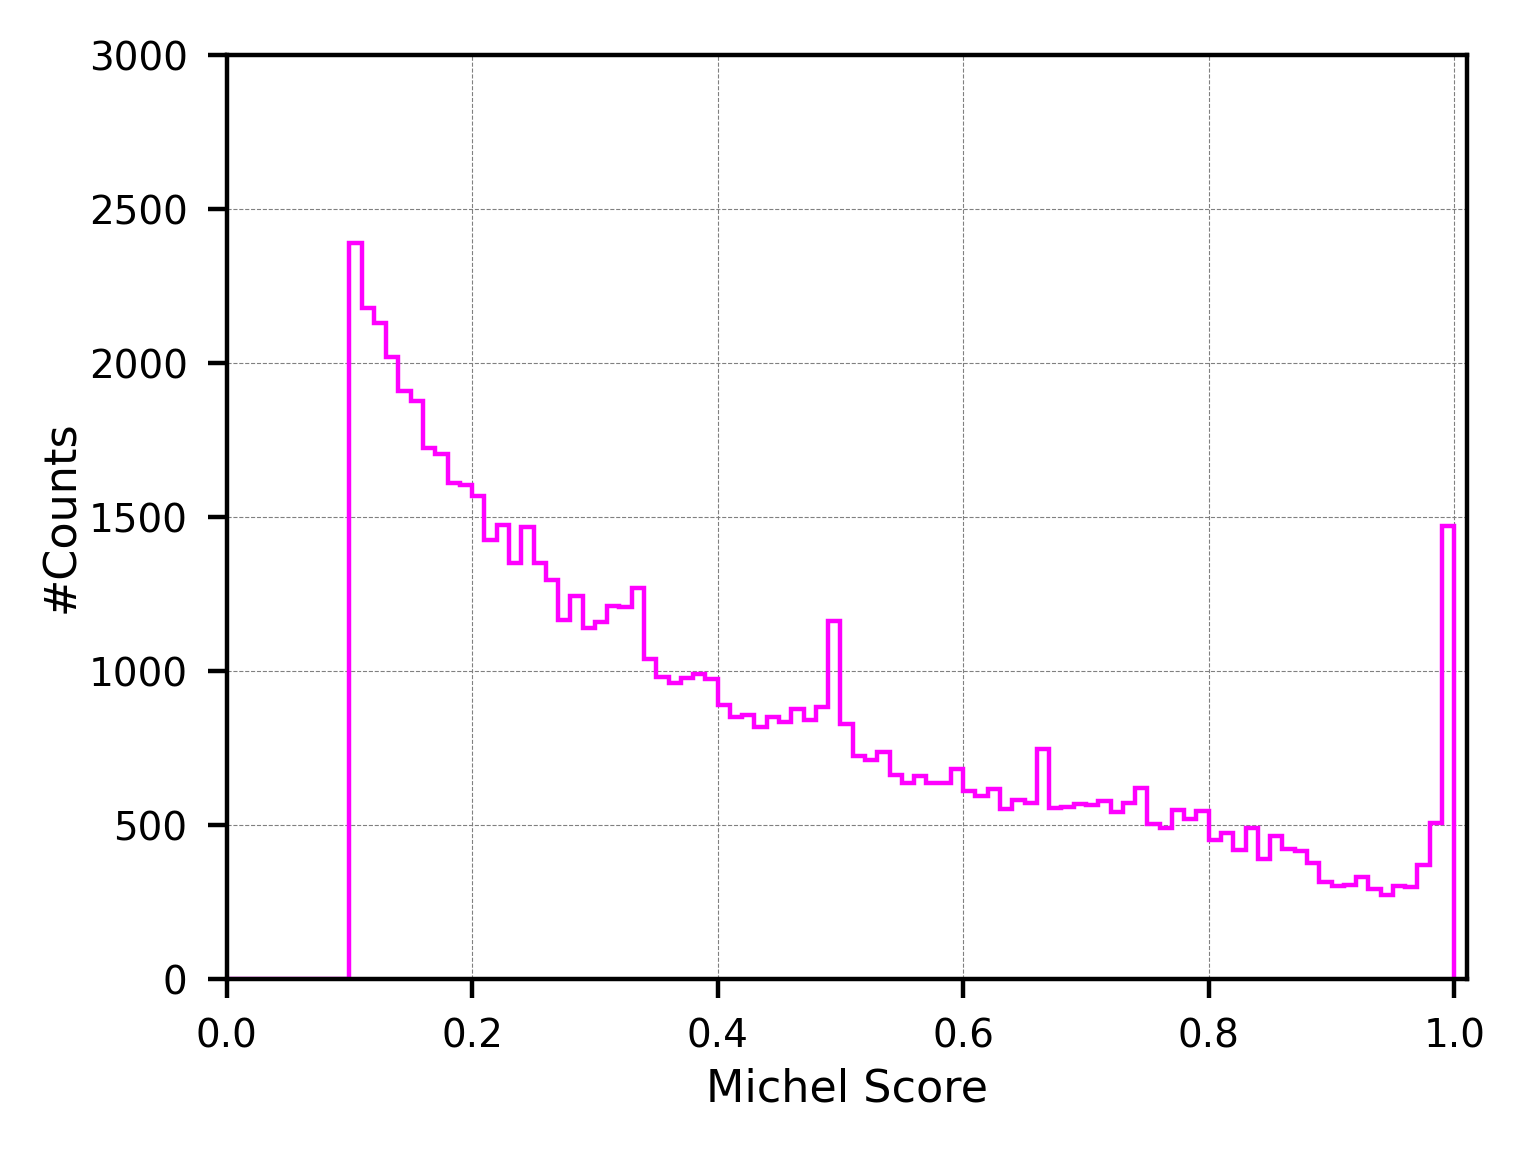

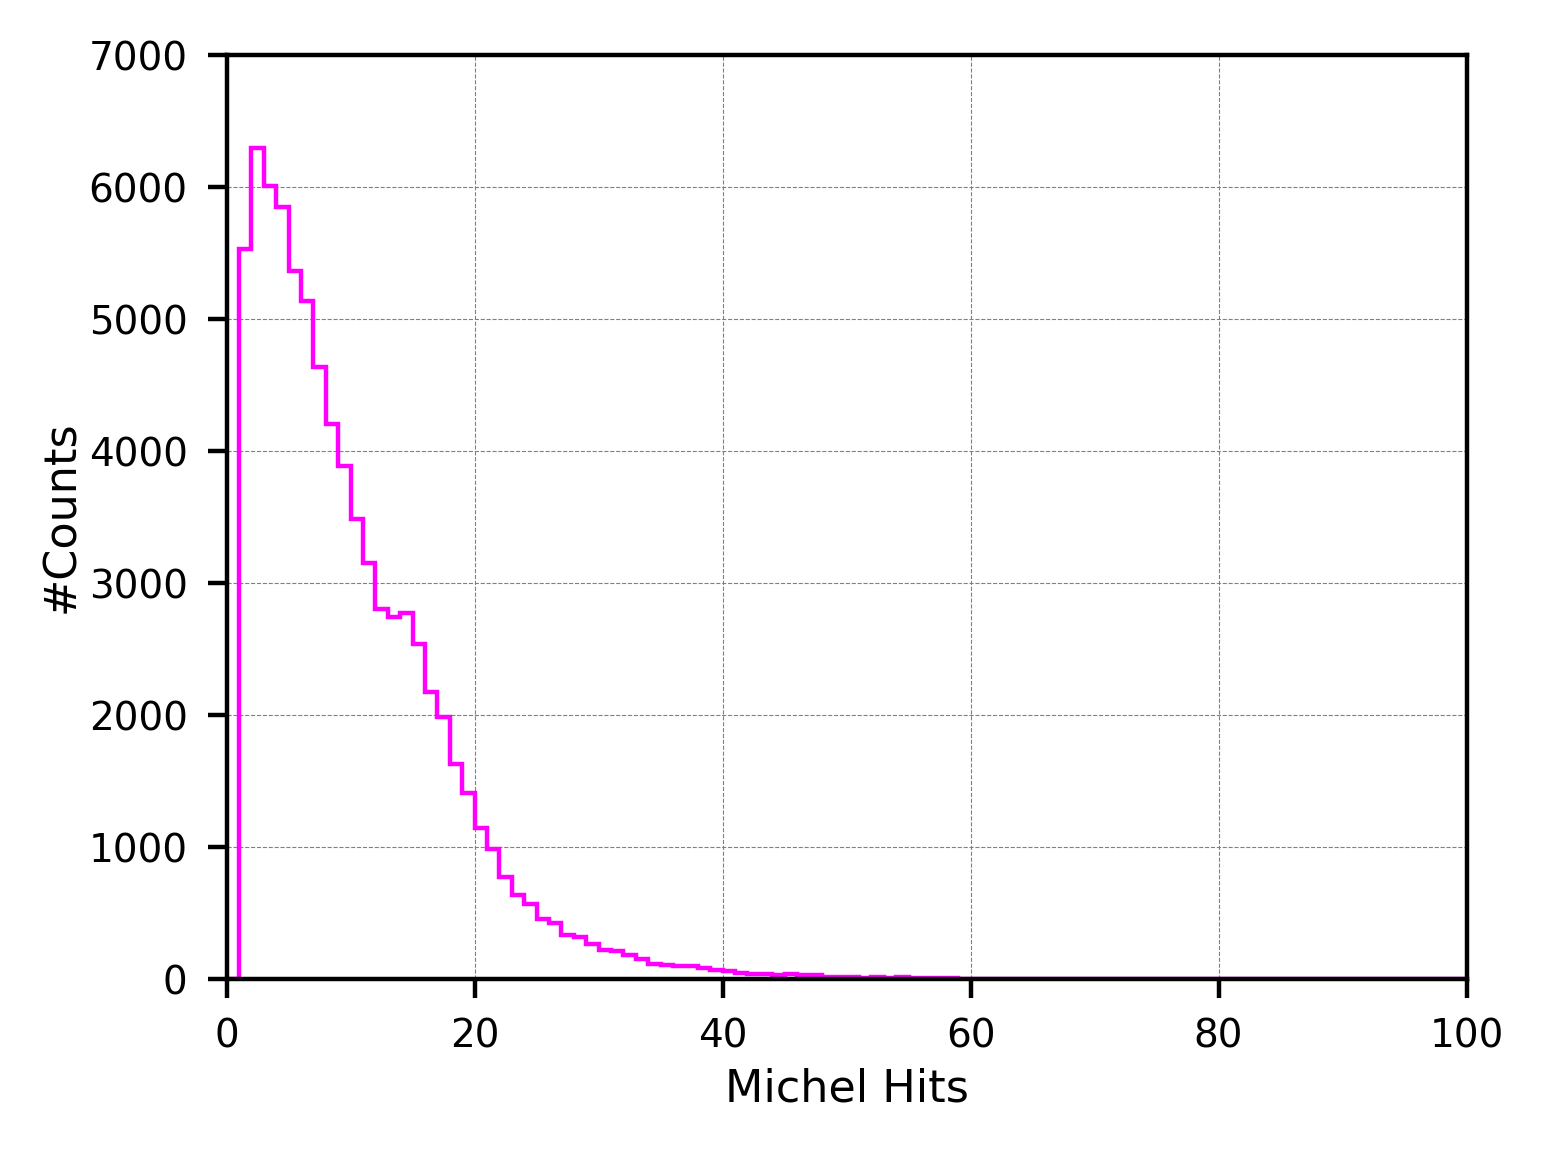

In [28]:

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayZ_initial, decayY_initial, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayZ_initial, decayX_initial, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayX_initial, decayY_initial, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(michelScore_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 1.01)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0, 3000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(michelHits_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 100)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0,7000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  



In [29]:
#After all cuts: Space, MS, MH---
cutX = []
cutY = []
cutZ = []
cutMS = []
cutMH = []


#Selection------
for i in range(0, len(decayX_initial)):
    X = decayX_initial[i]
    Y = decayY_initial[i]
    Z = decayZ_initial[i]
    MS = michelScore_initial[i]
    MH = michelHits_initial[i]
  
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if 0.4 < MS: #(Michel score cut)---
            
            if 5 < MH: #Michel hits cut---                
                cutX.append(X)
                cutY.append(Y)
                cutZ.append(Z)
                cutMS.append(MS)
                cutMH.append(MH)
            

#Initial size of dataset:-----
print("Size of X (initial) : ", len(decayX_initial))


print("\nSize of X (space cut & MS cut & MH cut) : ", len(cutX), "({:.3f}%)".format(len(cutX)/len(decayX_initial)*100))
print("Size of Y (space cut & MS cut & MH cut) : ", len(cutY))
print("Size of Z (space cut & MS cut & MH cut) : ", len(cutZ))
print("Size of MS (space cut & MS cut & MH cut): ", len(cutMS))
print("Size of MH (space cut & MS cut & MH cut): ", len(cutMH))

Size of X (initial) :  79286

Size of X (space cut & MS cut & MH cut) :  12757 (16.090%)
Size of Y (space cut & MS cut & MH cut) :  12757
Size of Z (space cut & MS cut & MH cut) :  12757
Size of MS (space cut & MS cut & MH cut):  12757
Size of MH (space cut & MS cut & MH cut):  12757


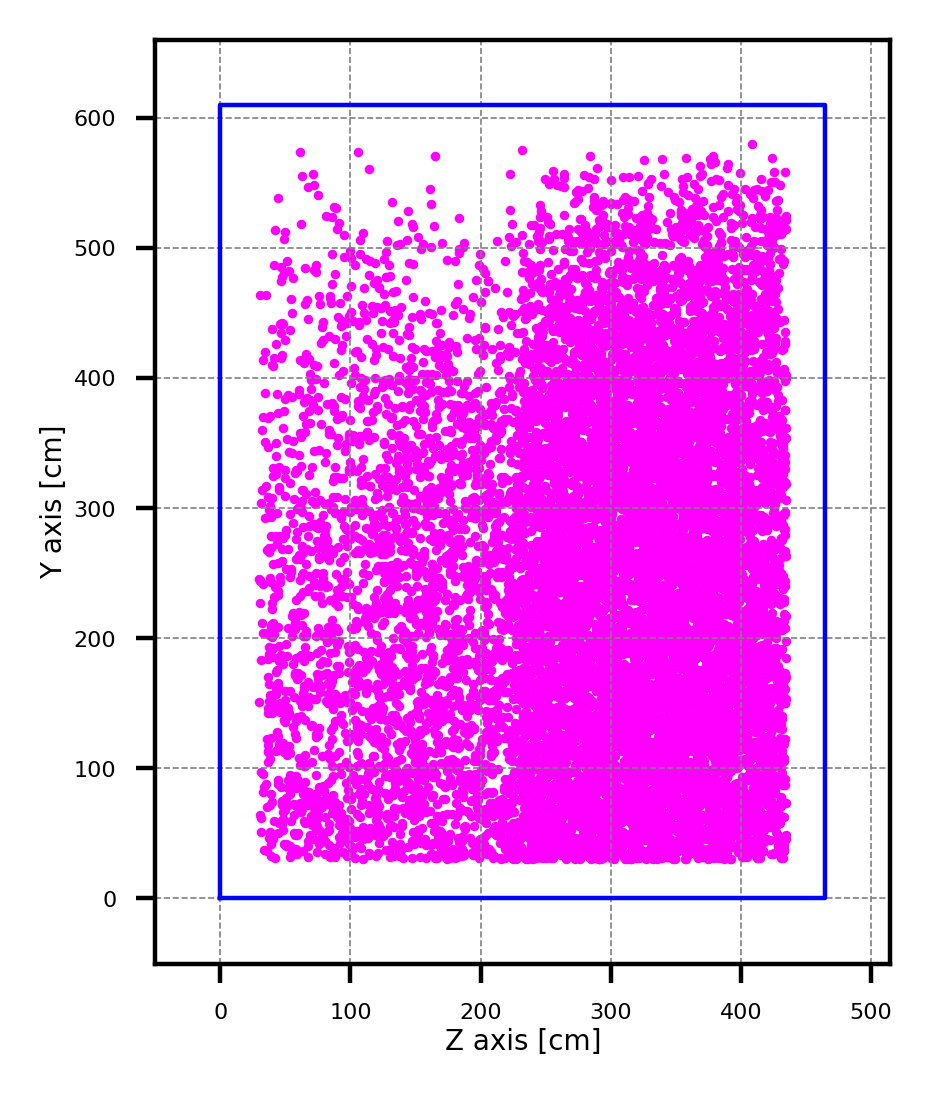

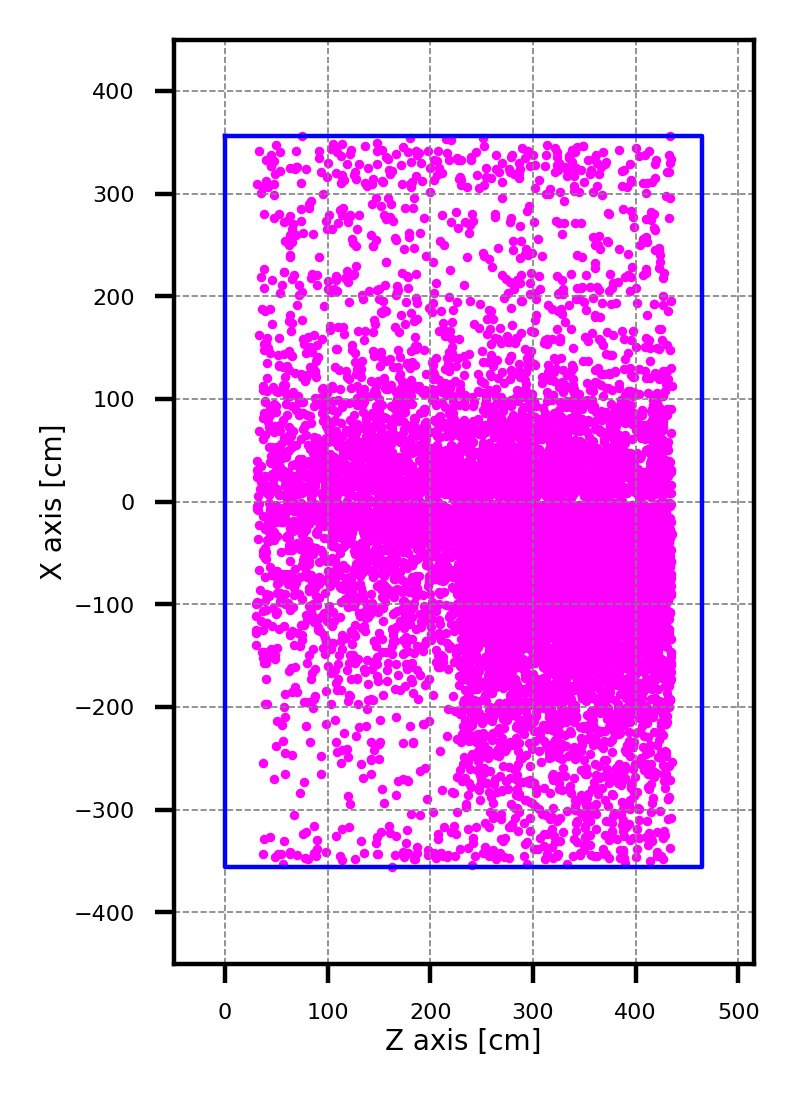

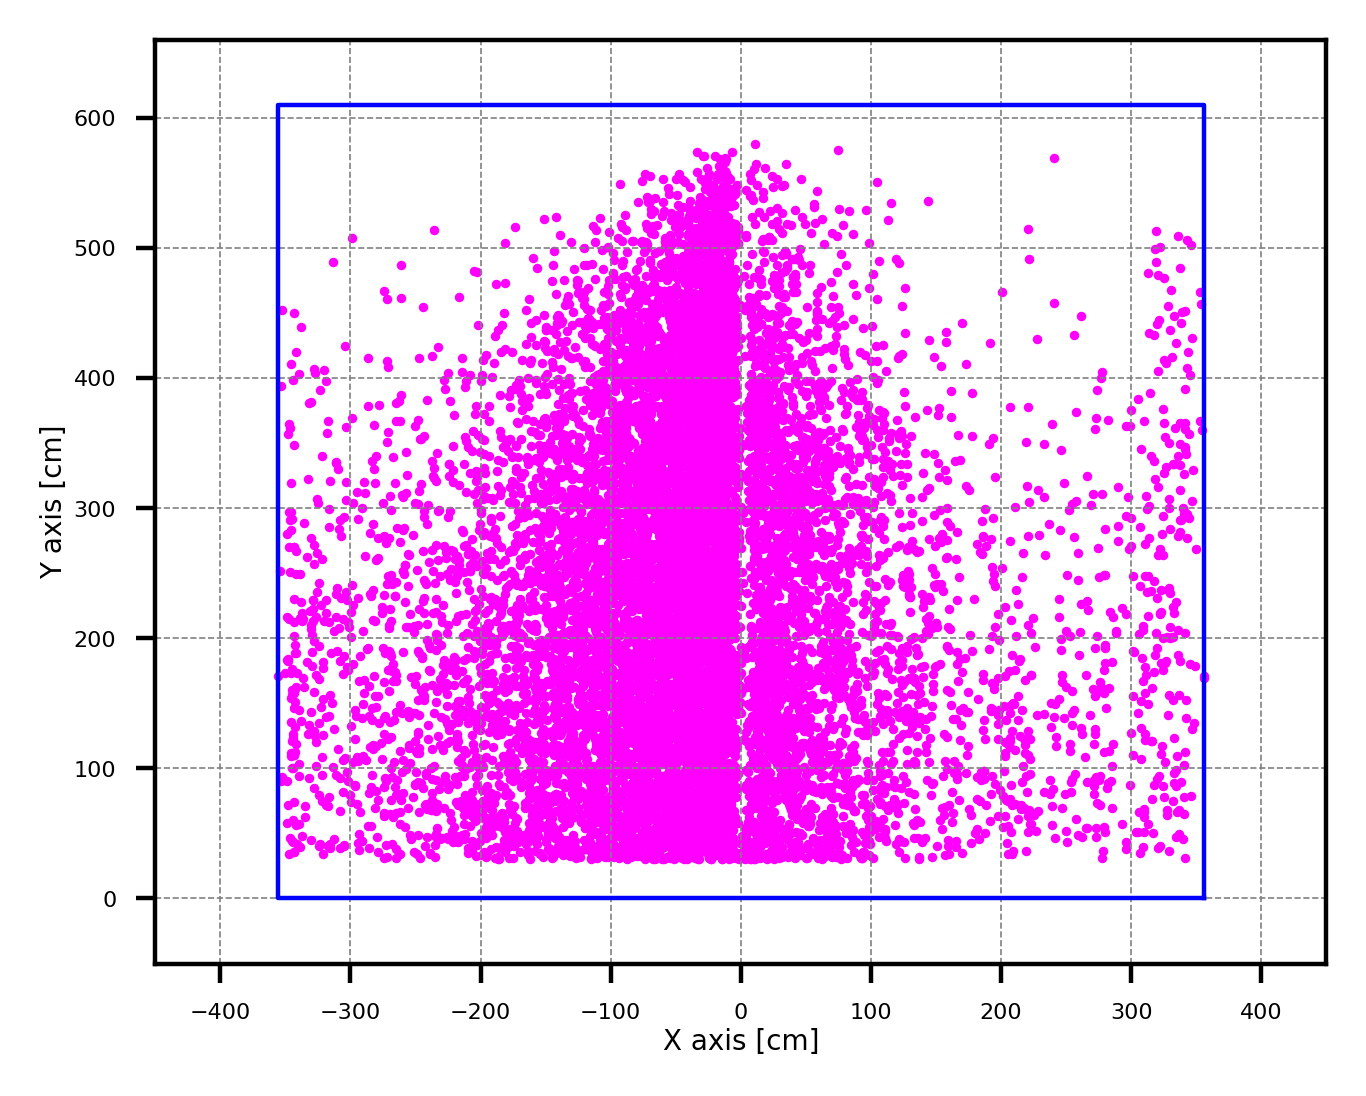

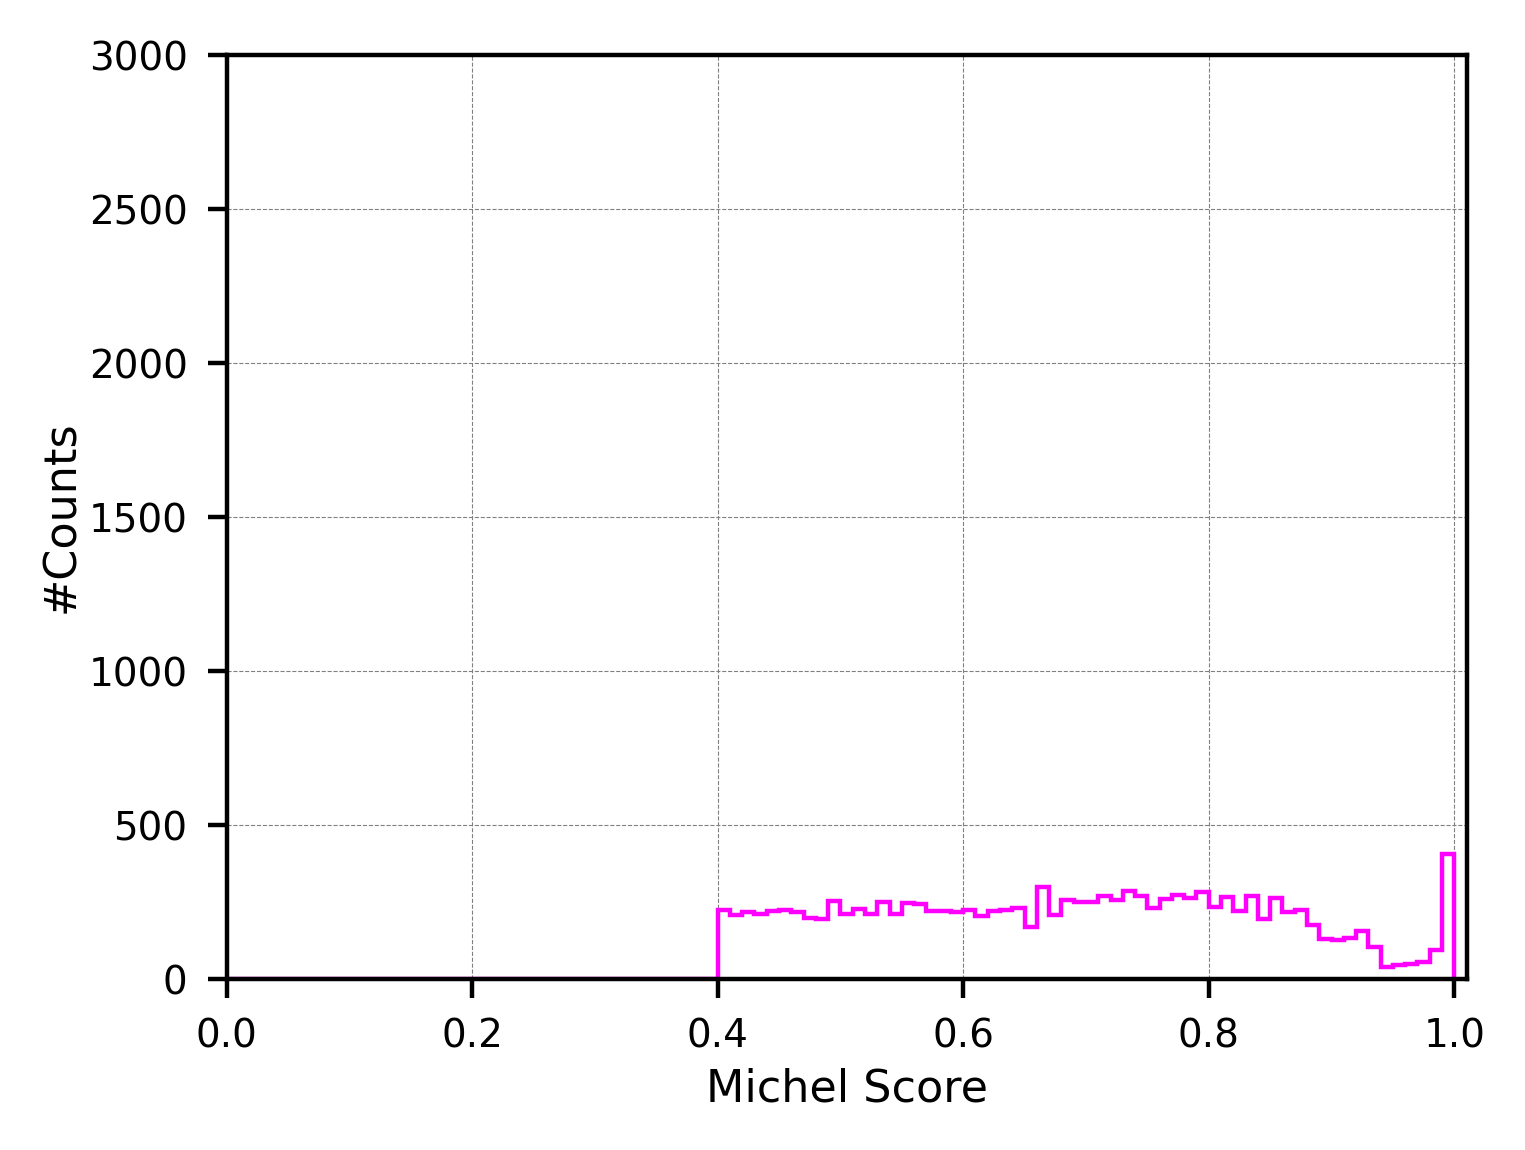

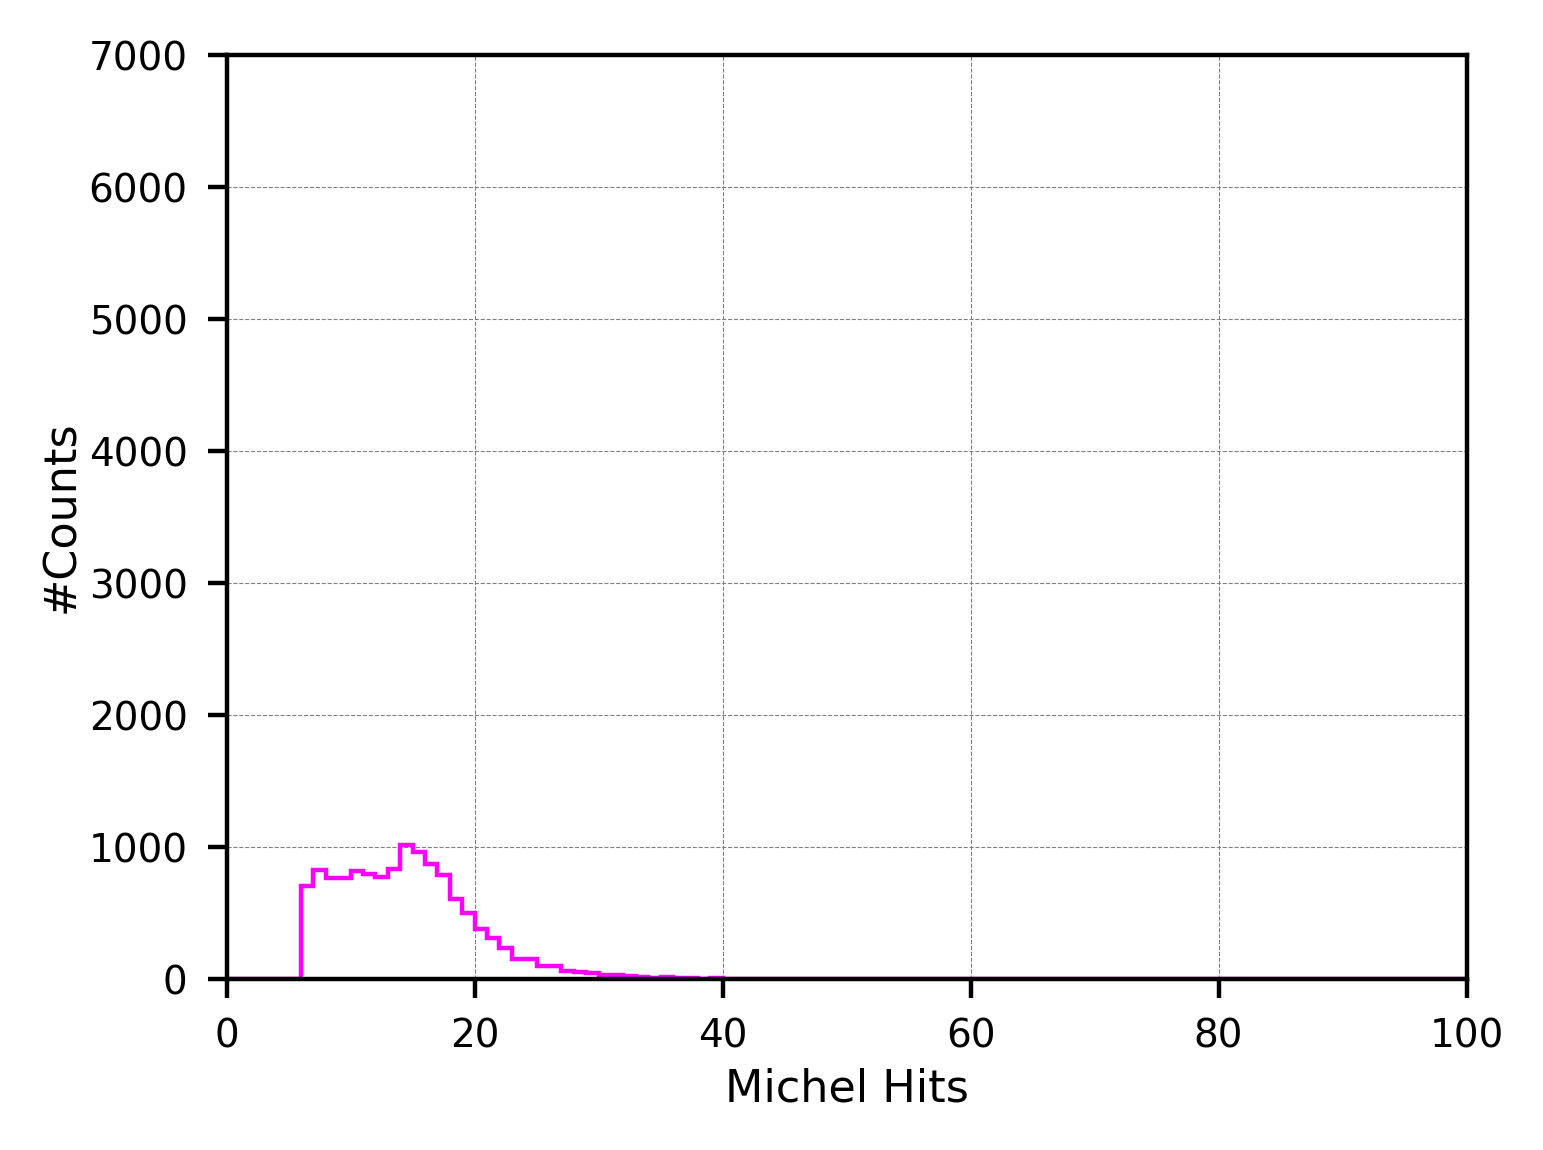

In [30]:
#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(cutZ, cutY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(cutZ, cutX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(cutX, cutY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(cutMS, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 1.01)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0, 3000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(cutMH, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 100)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0,7000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  

<br />
<br />
<br />
<br />


## Wvf Coincidence Cut Statistics:

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


# Specify the file name
#read data---
merged = []


with open('../statResult/print_wvfCoin_count.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                merged.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")


print("Intial event (track) candidates:  12757")
print("Length of PDS.                 : ", len(merged))

merged.extend([0] * 1335)

print("Length of merged: (+ 1335 0s): ", len(merged))


Intial event (track) candidates:  12757
Length of PDS.                 :  13382
Length of merged: (+ 1335 0s):  14717


Merged  (#wvf >= 5):  6545 (51.31%)


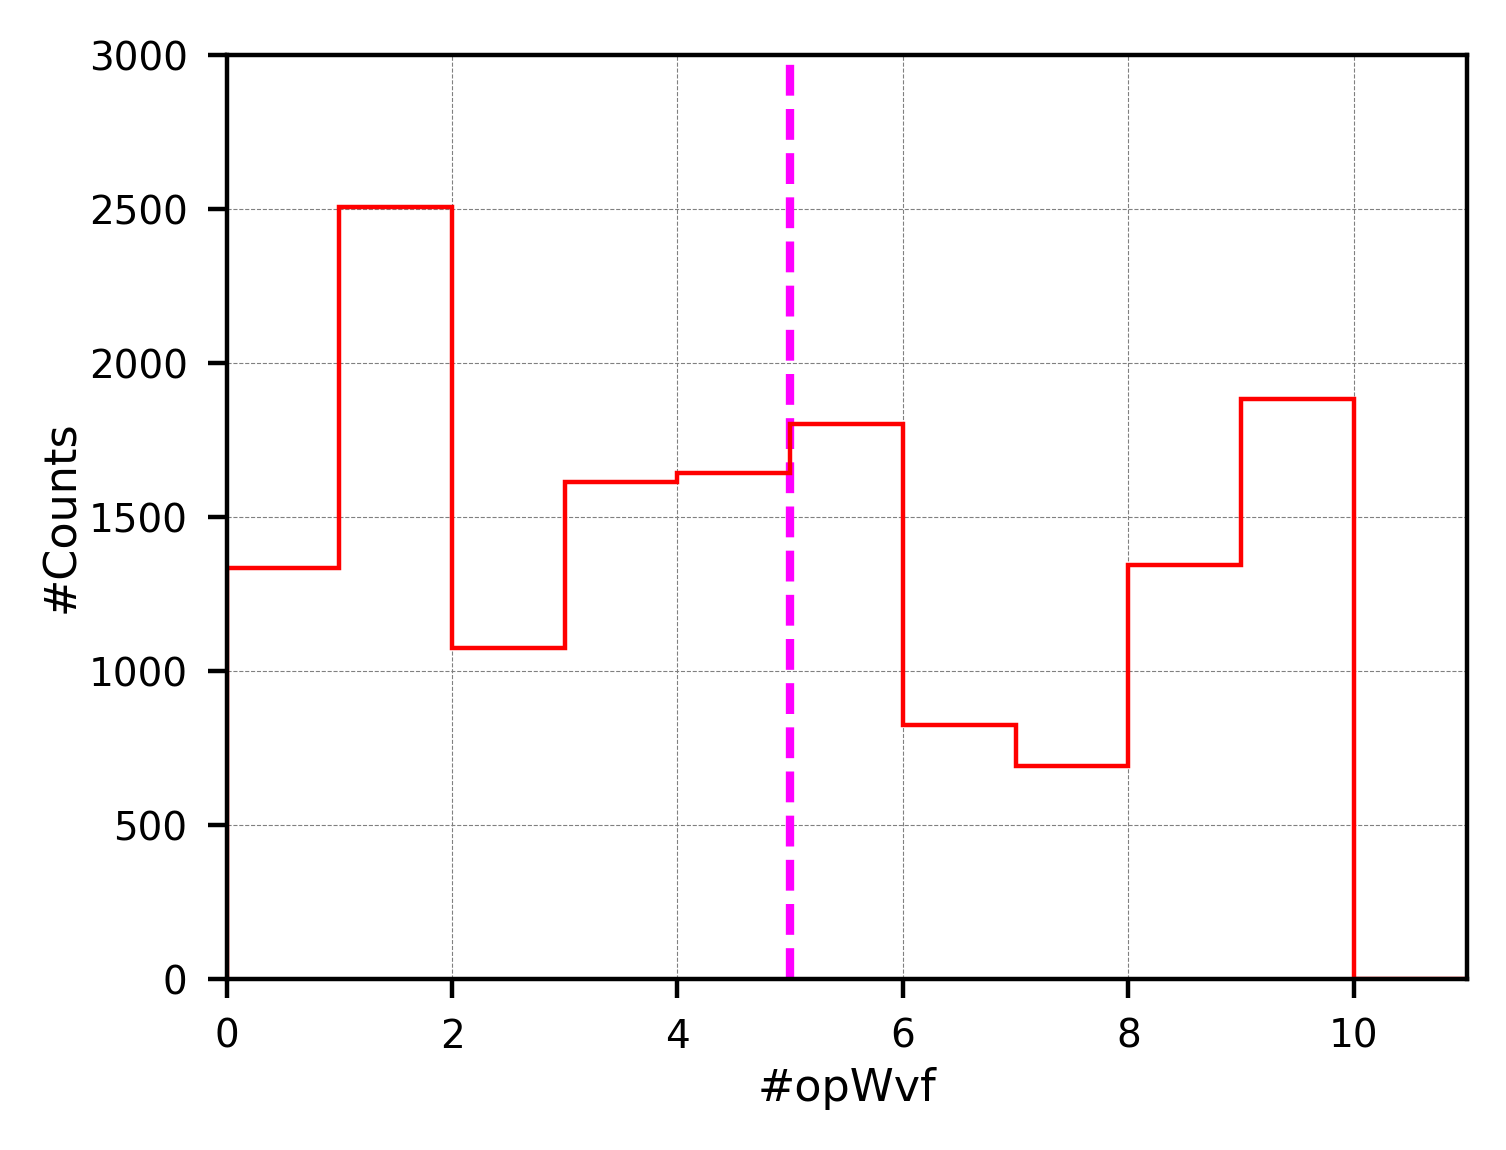

In [32]:
import matplotlib.pyplot as plt
import numpy as np


#Simple statistics------
num_merged_ge5 = sum(1 for x in merged if x >= 5)

#Event candidates (after space, MS & MH cuts): # = 1670
print("Merged  (#wvf >= 5): ", num_merged_ge5, "({:.2f}%)".format(num_merged_ge5/12757*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([5, 5], [0, 3000], color="magenta", linewidth=1.5, linestyle='--')

#plt.hist(noMerge, bins=bins, range=(range_min, range_max), edgecolor='blue', 
#         histtype='step', linewidth=0.8, label='NoMerge Result')
plt.hist(merged, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label='Merged Result')

#plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.ylim(0, 3000)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 
